# Cricket Performance Prediction — Data Modeling

## Overview
This notebook builds regression models to predict cricket player performance in IPL matches.

**Batting Model** — Predicts runs scored by a batter in a future match
**Bowling Model** — Predicts economy rate for a bowler in a future match

**Problem Type:** Regression (continuous target variable)

**Models Compared:**
- Linear Regression (Baseline)
- Ridge Regression (L2 Regularization)
- Lasso Regression (L1 Regularization)
- Elastic Net (Combined Regularization)
- Random Forest (Non-Linear Ensemble)

**Evaluation Metrics:** MAE, RMSE, R²
### Evaluation Metrics: MAE, RMSE, and R²

To evaluate model performance, we use **MAE, RMSE, and R²**, as each captures a different aspect of prediction quality.

#### 1. Mean Absolute Error (MAE)
MAE measures the average absolute difference between predicted and actual values. It is easy to interpret because it is expressed in the same units as the target variable.

**Interpretation:**  
How far the predictions are from actual values on average.

---

#### 2. Root Mean Squared Error (RMSE)
RMSE measures the square root of the average squared differences between predicted and actual values. It penalizes larger errors more than smaller ones.

**Interpretation:**  
Indicates whether the model is making large mistakes, as bigger errors have a stronger impact.

---

#### 3. R² (Coefficient of Determination)
R² measures how well the model explains the variability in the data. It indicates how much of the variation in the target variable is captured by the model.

**Interpretation:**  
Shows the overall goodness of fit of the model.

---

#### Why Use All Three?
- **MAE** → captures average error  
- **RMSE** → captures large error sensitivity  
- **R²** → captures overall model fit  

Using all three together provides a more complete and reliable evaluation of model performance.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All libraries loaded successfully.")






All libraries loaded successfully.



## Shared Utility Function

The `eval_regression` function prints MAE, RMSE and R² for any model
and any split. It is reused throughout both batting and bowling sections.

In [ ]:
def eval_regression(y_true, y_pred, label="Model"):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{label:35s} -> MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")

print("Utility function defined.")

Utility function defined.


# PART A — BATTING PERFORMANCE PREDICTION

**Target variable:** `runs` (continuous)
**Problem type:** Regression

**Features used:**
- Player identity, venue, match type, match stage, season
- Balls faced, strike rate, low score indicator
- Date-derived features: year, month, weekday

## Load Batting Dataset

We load the pre-cleaned batting CSV and inspect its shape and columns.
Each row represents one batter's performance in one match.

In [ ]:
batting_clean = pd.read_csv("batting_clean.csv")

print("Batting dataset shape:", batting_clean.shape)
print("\nColumn names:")
print(batting_clean.columns.tolist())
print("\nFirst 5 rows:")
batting_clean.head()


Batting dataset shape: (16515, 11)

Column names:
['match_id', 'player', 'runs', 'balls', 'strike_rate', 'low_score', 'season', 'date', 'venue', 'match_type', 'stage_bucket']

First 5 rows:


,match_id,player,runs,balls,strike_rate,low_score,season,date,venue,match_type,stage_bucket
0,335982,AA Noffke,9,12,75.000000,1,2007/08,2008-04-18,M Chinnaswamy Stadium,League,league
1,335982,B Akhil,0,2,0.000000,1,2007/08,2008-04-18,M Chinnaswamy Stadium,League,league
2,335982,BB McCullum,158,77,205.194805,0,2007/08,2008-04-18,M Chinnaswamy Stadium,League,league
3,335982,CL White,6,10,60.000000,1,2007/08,2008-04-18,M Chinnaswamy Stadium,League,league
4,335982,DJ Hussey,12,12,100.000000,0,2007/08,2008-04-18,M Chinnaswamy Stadium,League,league



## Feature Engineering — Date Variables

Raw date strings cannot be used directly by ML models.
We extract three numeric features from the date column:

- `match_year`    — year the match was played
- `match_month`   — month (1–12), captures seasonality  
- `match_weekday` — day of week (0 = Monday, 6 = Sunday)

The raw date column is then dropped.

In [ ]:
batting_clean["date"] = pd.to_datetime(batting_clean["date"], errors="coerce")

batting_clean["match_year"]    = batting_clean["date"].dt.year
batting_clean["match_month"]   = batting_clean["date"].dt.month
batting_clean["match_weekday"] = batting_clean["date"].dt.weekday

batting_clean = batting_clean.drop(columns=["date"])

print("Date features added. Updated shape:", batting_clean.shape)


Date features added. Updated shape: (16515, 13)




## Define Features and Target

Target = `runs`

We separate the feature matrix X from the target variable y.

In [ ]:
target_bat = "runs"
X_bat = batting_clean.drop(columns=[target_bat])
y_bat = batting_clean[target_bat]

print("Feature matrix shape:", X_bat.shape)
print("Target variable     :", target_bat)

Feature matrix shape: (16515, 12)
Target variable     : runs


## Train / Validation / Test Split (70 / 15 / 15)

We use a random split for the baseline batting model.
The dataset is split into:
- **Training set (70%)** — used to fit all models
- **Validation set (15%)** — used to compare models
- **Test set (15%)** — used for final unbiased evaluation

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_bat, y_bat, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Batting Train:", X_train.shape)
print("Batting Val  :", X_val.shape)
print("Batting Test :", X_test.shape)

# Store for later use
X_train_bat = X_train
X_val_bat   = X_val
X_test_bat  = X_test
y_train_bat = y_train
y_val_bat   = y_val
y_test_bat  = y_test


Batting Train: (11560, 12)
Batting Val  : (2477, 12)
Batting Test : (2478, 12)



## Preprocessing Pipeline

Two sub-pipelines handle the two types of features:

**Categorical features** (player, venue, match_type, season, stage_bucket):
- Missing values imputed with most frequent value
- One-Hot Encoded (unknown categories at test time are ignored)

**Numeric features** (all remaining columns):
- Missing values imputed with column median
- Standardised with StandardScaler (zero mean, unit variance)

Both are combined using ColumnTransformer.

In [ ]:
categorical_cols_bat = [
    "player", "season", "venue", "match_type", "stage_bucket"
]
numeric_cols_bat = [
    c for c in X_bat.columns
    if c not in categorical_cols_bat
]

cat_pipe_bat = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe",     OneHotEncoder(handle_unknown="ignore"))
])

num_pipe_bat = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

preprocess_bat = ColumnTransformer(transformers=[
    ("cat", cat_pipe_bat, categorical_cols_bat),
    ("num", num_pipe_bat, numeric_cols_bat),
])

print("Categorical features:", categorical_cols_bat)
print("Numeric features    :", numeric_cols_bat)
print("\nPreprocessing pipeline built successfully.")

Categorical features: ['player', 'season', 'venue', 'match_type', 'stage_bucket']
Numeric features    : ['match_id', 'balls', 'strike_rate', 'low_score', 'match_year', 'match_month', 'match_weekday']

Preprocessing pipeline built successfully.


## Model 1 — Linear Regression (Baseline)

Linear Regression fits a weighted sum of all input features to predict runs.
It serves as the baseline against which all other models are compared.

**Diagnosing underfitting vs overfitting:**
- Train error << Validation error → likely overfitting
- Both errors are high → likely underfitting
- Train and Validation are close → good generalisation

In [ ]:
bat_model = Pipeline(steps=[
    ("preprocess", preprocess_bat),
    ("model",      LinearRegression())
])

bat_model.fit(X_train_bat, y_train_bat)

print("=== Linear Regression — Batting ===")
eval_regression(y_train_bat, bat_model.predict(X_train_bat), "Batting Train")
eval_regression(y_val_bat,   bat_model.predict(X_val_bat),   "Batting Val  ")
eval_regression(y_test_bat,  bat_model.predict(X_test_bat),  "Batting Test ")

=== Linear Regression — Batting ===
Batting Train                       -> MAE: 4.0141 | RMSE: 5.8062 | R2: 0.9264
Batting Val                         -> MAE: 4.1944 | RMSE: 6.0279 | R2: 0.9207
Batting Test                        -> MAE: 4.2790 | RMSE: 6.0640 | R2: 0.9176


## Batting Model — Time-Based Split

To evaluate genuine generalisation across seasons, we also split
the batting data chronologically:

| Split      | Seasons     | Purpose                       |
|------------|-------------|-------------------------------|
| Train      | 2008 – 2021 | Fit all models                |
| Validation | 2022        | Compare models                |
| Test       | 2023 – 2024 | Final unbiased evaluation     |

In [ ]:
batting_clean["season_year"] = batting_clean["season"].str[:4].astype(int)

train = batting_clean[batting_clean["season_year"] <= 2021].copy()
val   = batting_clean[batting_clean["season_year"] == 2022].copy()
test  = batting_clean[batting_clean["season_year"] >= 2023].copy()

print(train.shape, val.shape, test.shape)

target    = "runs"
drop_cols = ["runs"]

X_train = train.drop(columns=drop_cols)
y_train = train[target]
X_val   = val.drop(columns=drop_cols)
y_val   = val[target]
X_test  = test.drop(columns=drop_cols)
y_test  = test[target]

print("\nTrain columns:")
print(X_train.columns.tolist())

(13071, 14) (1158, 14) (2286, 14)

Train columns:
['match_id', 'player', 'balls', 'strike_rate', 'low_score', 'season', 'venue', 'match_type', 'stage_bucket', 'match_year', 'match_month', 'match_weekday', 'season_year']


In [ ]:
categorical_cols = [
    "player", "season", "venue", "match_type", "stage_bucket"
]
numeric_cols = [
    c for c in X_train.columns
    if c not in categorical_cols
]

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe",     OneHotEncoder(handle_unknown="ignore"))
])

num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

preprocess = ColumnTransformer(transformers=[
    ("cat", cat_pipeline, categorical_cols),
    ("num", num_pipeline, numeric_cols)
])

bat_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model",      LinearRegression())
])

bat_model.fit(X_train, y_train)

print("=== Linear Regression — Batting (Time-Based Split) ===")
eval_regression(y_train, bat_model.predict(X_train), "Batting Train")
eval_regression(y_val,   bat_model.predict(X_val),   "Batting Val  ")
eval_regression(y_test,  bat_model.predict(X_test),  "Batting Test ")

X_train_bat = X_train
X_val_bat   = X_val
X_test_bat  = X_test
y_train_bat = y_train
y_val_bat   = y_val
y_test_bat  = y_test


=== Linear Regression — Batting (Time-Based Split) ===
Batting Train                       -> MAE: 3.9732 | RMSE: 5.7938 | R2: 0.9244
Batting Val                         -> MAE: 4.2471 | RMSE: 5.9634 | R2: 0.9232
Batting Test                        -> MAE: 5.2160 | RMSE: 7.4496 | R2: 0.8931



---
# PART B — BOWLING PERFORMANCE PREDICTION

**Target variable:** `economy` (continuous)
**Problem type:** Regression

**Features used:**
- Bowler identity, venue, match type, match stage, season
- Balls bowled, runs conceded, wickets, dot balls
- Overs, strike rate (balls per wicket), dot ball rate
- Date-derived features: year, month, weekday

The bowling dataset is split **chronologically** to avoid
temporal data leakage.

| Split      | Seasons     |
|------------|-------------|
| Train      | 2008 – 2021 |
| Validation | 2022        |
| Test       | 2023 – 2024 |





## Load Bowling Dataset

In [ ]:
bowling_clean = pd.read_csv("bowling_clean.csv")

print("Bowling dataset shape:", bowling_clean.shape)
print("\nColumn names:")
print(bowling_clean.columns.tolist())
print("\nFirst 5 rows:")
bowling_clean.head()

Bowling dataset shape: (12978, 17)

Column names:
['match_id', 'bowler', 'balls', 'runs_conceded', 'wides', 'no_balls', 'wickets', 'dot_balls', 'overs', 'economy', 'strike_rate_balls_per_wicket', 'dot_ball_rate', 'season', 'date', 'venue', 'match_type', 'stage_bucket']

First 5 rows:


,match_id,bowler,balls,runs_conceded,wides,no_balls,wickets,dot_balls,overs,economy,strike_rate_balls_per_wicket,dot_ball_rate,season,date,venue,match_type,stage_bucket
0,335982,AA Noffke,25,41,0,0,1,6,4.166667,9.840000,25.000000,0.240000,2007/08,2008-04-18,M Chinnaswamy Stadium,League,league
1,335982,AB Agarkar,28,25,0,0,3,15,4.666667,5.357143,9.333333,0.535714,2007/08,2008-04-18,M Chinnaswamy Stadium,League,league
2,335982,AB Dinda,20,9,0,0,2,11,3.333333,2.700000,10.000000,0.550000,2007/08,2008-04-18,M Chinnaswamy Stadium,League,league
3,335982,CL White,7,24,0,0,0,0,1.166667,20.571429,NaN,0.000000,2007/08,2008-04-18,M Chinnaswamy Stadium,League,league
4,335982,I Sharma,19,13,0,0,1,10,3.166667,4.105263,19.000000,0.526316,2007/08,2008-04-18,M Chinnaswamy Stadium,League,league


## Feature Engineering — Date Variables

In [ ]:
bowling_clean["season_year"] = (
    bowling_clean["season"].astype(str).str[:4].astype(int)
)

bowling_clean["date"]         = pd.to_datetime(
    bowling_clean["date"], errors="coerce"
)
bowling_clean["match_year"]    = bowling_clean["date"].dt.year
bowling_clean["match_month"]   = bowling_clean["date"].dt.month
bowling_clean["match_weekday"] = bowling_clean["date"].dt.weekday
bowling_clean = bowling_clean.drop(columns=["date"])

print("Date features added. Updated shape:", bowling_clean.shape)


Date features added. Updated shape: (12978, 20)



## Time-Based Split and Preprocessing

In [ ]:
train_bowl = bowling_clean[bowling_clean["season_year"] <= 2021].copy()
val_bowl   = bowling_clean[bowling_clean["season_year"] == 2022].copy()
test_bowl  = bowling_clean[bowling_clean["season_year"] >= 2023].copy()

target_bowl = "economy"

X_train_bowl = train_bowl.drop(columns=[target_bowl])
y_train_bowl = train_bowl[target_bowl]
X_val_bowl   = val_bowl.drop(columns=[target_bowl])
y_val_bowl   = val_bowl[target_bowl]
X_test_bowl  = test_bowl.drop(columns=[target_bowl])
y_test_bowl  = test_bowl[target_bowl]

print(f"Bowling Train : {X_train_bowl.shape}")
print(f"Bowling Val   : {X_val_bowl.shape}")
print(f"Bowling Test  : {X_test_bowl.shape}")


Bowling Train : (10366, 19)
Bowling Val   : (857, 19)
Bowling Test  : (1755, 19)



## Preprocessing Pipeline

**Categorical columns** — One-Hot Encoding with most-frequent imputation

**Numeric columns** — Median imputation + StandardScaler

This avoids errors caused by NaN values and text features.

In [ ]:
categorical_cols_bowl = [
    "bowler", "season", "venue", "match_type", "stage_bucket"
]
categorical_cols_bowl = [
    c for c in categorical_cols_bowl
    if c in X_train_bowl.columns
]
numeric_cols_bowl = [
    c for c in X_train_bowl.columns
    if c not in categorical_cols_bowl
]

cat_pipe_bowl = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe",     OneHotEncoder(handle_unknown="ignore"))
])

num_pipe_bowl = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

preprocess_bowl = ColumnTransformer(transformers=[
    ("cat", cat_pipe_bowl, categorical_cols_bowl),
    ("num", num_pipe_bowl, numeric_cols_bowl),
])

print("Categorical features:", categorical_cols_bowl)
print("Numeric features    :", numeric_cols_bowl)
print("\nPreprocessing pipeline built successfully.")


Categorical features: ['bowler', 'season', 'venue', 'match_type', 'stage_bucket']
Numeric features    : ['match_id', 'balls', 'runs_conceded', 'wides', 'no_balls', 'wickets', 'dot_balls', 'overs', 'strike_rate_balls_per_wicket', 'dot_ball_rate', 'season_year', 'match_year', 'match_month', 'match_weekday']

Preprocessing pipeline built successfully.


In [ ]:
# Retrain the baseline bowling linear regression model
bowl_model = Pipeline(steps=[
    ("preprocess", preprocess_bowl),
    ("model",      LinearRegression())
])
bowl_model.fit(X_train_bowl, y_train_bowl)

print("Bowling baseline model trained.")

Bowling baseline model trained.



---
# PART C — MODEL COMPARISON

We train and evaluate six models on both batting and bowling datasets.
Results are compared using Test Set R².

| Model             | Type            | Key Property                        |
|-------------------|-----------------|-------------------------------------|
| Linear Regression | Linear          | Baseline, no regularisation         |
| Ridge             | Linear + L2     | Shrinks large coefficients          |
| Lasso             | Linear + L1     | Can zero out weak features          |
| Elastic Net       | Linear + L1+L2  | Balances Ridge and Lasso            |
| Random Forest     | Non-Linear      | Captures complex interactions       |
| Gradient Boosting | Non-Linear      | Sequential error correction         |


## Ridge Regression (L2 Regularization)

Ridge reduces overfitting by penalising large coefficients.
This helps improve generalisation, especially when features are
correlated or noisy.

**Alpha = 10** controls regularisation strength.
Higher alpha → stronger shrinkage.

In [ ]:
# Batting
ridge_bat = Pipeline([
    ("preprocess", preprocess_bat),
    ("model",      Ridge(alpha=10))
])
ridge_bat.fit(X_train_bat, y_train_bat)

print("=== Ridge Regression — Batting ===")
eval_regression(y_train_bat, ridge_bat.predict(X_train_bat), "Train")
eval_regression(y_val_bat,   ridge_bat.predict(X_val_bat),   "Val  ")
eval_regression(y_test_bat,  ridge_bat.predict(X_test_bat),  "Test ")

# Bowling
ridge_bowl = Pipeline([
    ("preprocess", preprocess_bowl),
    ("model",      Ridge(alpha=10))
])
ridge_bowl.fit(X_train_bowl, y_train_bowl)

print("\n=== Ridge Regression — Bowling ===")
eval_regression(y_train_bowl, ridge_bowl.predict(X_train_bowl), "Train")
eval_regression(y_val_bowl,   ridge_bowl.predict(X_val_bowl),   "Val  ")
eval_regression(y_test_bowl,  ridge_bowl.predict(X_test_bowl),  "Test ")


=== Ridge Regression — Batting ===
Train                               -> MAE: 3.9863 | RMSE: 5.8365 | R2: 0.9233
Val                                 -> MAE: 4.1183 | RMSE: 5.7481 | R2: 0.9287
Test                                -> MAE: 4.3575 | RMSE: 6.4991 | R2: 0.9187

=== Ridge Regression — Bowling ===
Train                               -> MAE: 0.5421 | RMSE: 0.9976 | R2: 0.8845
Val                                 -> MAE: 0.5912 | RMSE: 1.2666 | R2: 0.8355
Test                                -> MAE: 0.6485 | RMSE: 1.2349 | R2: 0.8611



## Lasso Regression (L1 Regularization)

Lasso can shrink some feature coefficients to exactly zero,
performing automatic feature selection. This is useful when
many features have little predictive value.

In [ ]:
# Batting
lasso_bat = Pipeline([
    ("preprocess", preprocess_bat),
    ("model",      Lasso(alpha=0.1))
])
lasso_bat.fit(X_train_bat, y_train_bat)

print("=== Lasso Regression — Batting ===")
eval_regression(y_train_bat, lasso_bat.predict(X_train_bat), "Train")
eval_regression(y_val_bat,   lasso_bat.predict(X_val_bat),   "Val  ")
eval_regression(y_test_bat,  lasso_bat.predict(X_test_bat),  "Test ")

# Bowling
lasso_bowl = Pipeline([
    ("preprocess", preprocess_bowl),
    ("model",      Lasso(alpha=0.1))
])
lasso_bowl.fit(X_train_bowl, y_train_bowl)

print("\n=== Lasso Regression — Bowling ===")
eval_regression(y_train_bowl, lasso_bowl.predict(X_train_bowl), "Train")
eval_regression(y_val_bowl,   lasso_bowl.predict(X_val_bowl),   "Val  ")
eval_regression(y_test_bowl,  lasso_bowl.predict(X_test_bowl),  "Test ")


=== Lasso Regression — Batting ===
Train                               -> MAE: 4.0254 | RMSE: 6.0243 | R2: 0.9183
Val                                 -> MAE: 4.0564 | RMSE: 5.7728 | R2: 0.9281
Test                                -> MAE: 4.3221 | RMSE: 6.6028 | R2: 0.9160

=== Lasso Regression — Bowling ===
Train                               -> MAE: 0.6741 | RMSE: 1.2723 | R2: 0.8122
Val                                 -> MAE: 0.6781 | RMSE: 1.5279 | R2: 0.7606
Test                                -> MAE: 0.7829 | RMSE: 1.5276 | R2: 0.7874



## Elastic Net (Combined Regularization)

Elastic Net combines both L1 (Lasso) and L2 (Ridge) regularisation.
The `l1_ratio` parameter balances between the two:
- l1_ratio = 1.0 → pure Lasso
- l1_ratio = 0.0 → pure Ridge
- l1_ratio = 0.5 → equal mix (used here)

In [ ]:
# Batting
elastic_bat = Pipeline([
    ("preprocess", preprocess_bat),
    ("model",      ElasticNet(alpha=0.1, l1_ratio=0.5))
])
elastic_bat.fit(X_train_bat, y_train_bat)

print("=== Elastic Net — Batting ===")
eval_regression(y_train_bat, elastic_bat.predict(X_train_bat), "Train")
eval_regression(y_val_bat,   elastic_bat.predict(X_val_bat),   "Val  ")
eval_regression(y_test_bat,  elastic_bat.predict(X_test_bat),  "Test ")

# Bowling
elastic_bowl = Pipeline([
    ("preprocess", preprocess_bowl),
    ("model",      ElasticNet(alpha=0.1, l1_ratio=0.5))
])
elastic_bowl.fit(X_train_bowl, y_train_bowl)

print("\n=== Elastic Net — Bowling ===")
eval_regression(y_train_bowl, elastic_bowl.predict(X_train_bowl), "Train")
eval_regression(y_val_bowl,   elastic_bowl.predict(X_val_bowl),   "Val  ")
eval_regression(y_test_bowl,  elastic_bowl.predict(X_test_bowl),  "Test ")


=== Elastic Net — Batting ===
Train                               -> MAE: 4.0742 | RMSE: 6.1659 | R2: 0.9144
Val                                 -> MAE: 4.2138 | RMSE: 5.9737 | R2: 0.9230
Test                                -> MAE: 4.5384 | RMSE: 6.9498 | R2: 0.9070

=== Elastic Net — Bowling ===
Train                               -> MAE: 0.7027 | RMSE: 1.2937 | R2: 0.8058
Val                                 -> MAE: 0.7117 | RMSE: 1.5435 | R2: 0.7557
Test                                -> MAE: 0.8181 | RMSE: 1.5613 | R2: 0.7779



## Random Forest Regression (Non-Linear Model)

Random Forest is a tree-based ensemble that builds multiple decision
trees on random subsets of data and features, then averages their
predictions. It captures nonlinear relationships and feature interactions.

**Hyperparameters:**
- `n_estimators = 50` — number of trees
- `max_depth = 4-5` — prevents overfitting by limiting tree depth
- `random_state = 42` — ensures reproducibility

In [ ]:
# Batting
rf_bat = Pipeline([
    ("preprocess", preprocess_bat),
    ("model",      RandomForestRegressor(
        n_estimators=50,
        max_depth=4,
        random_state=42
    ))
])
rf_bat.fit(X_train_bat, y_train_bat)

print("=== Random Forest — Batting ===")
eval_regression(y_train_bat, rf_bat.predict(X_train_bat), "Train")
eval_regression(y_val_bat,   rf_bat.predict(X_val_bat),   "Val  ")
eval_regression(y_test_bat,  rf_bat.predict(X_test_bat),  "Test ")

# Bowling
rf_bowl = Pipeline([
    ("preprocess", preprocess_bowl),
    ("model",      RandomForestRegressor(
        n_estimators=50,
        max_depth=5,
        random_state=42
    ))
])
rf_bowl.fit(X_train_bowl, y_train_bowl)

print("\n=== Random Forest — Bowling ===")
eval_regression(y_train_bowl, rf_bowl.predict(X_train_bowl), "Train")
eval_regression(y_val_bowl,   rf_bowl.predict(X_val_bowl),   "Val  ")
eval_regression(y_test_bowl,  rf_bowl.predict(X_test_bowl),  "Test ")



=== Random Forest — Batting ===
Train                               -> MAE: 2.7762 | RMSE: 4.2299 | R2: 0.9597
Val                                 -> MAE: 2.8334 | RMSE: 4.2441 | R2: 0.9611
Test                                -> MAE: 3.1693 | RMSE: 5.0626 | R2: 0.9506

=== Random Forest — Bowling ===
Train                               -> MAE: 0.7373 | RMSE: 1.1523 | R2: 0.8460
Val                                 -> MAE: 0.7732 | RMSE: 1.3408 | R2: 0.8156
Test                                -> MAE: 0.9222 | RMSE: 1.5481 | R2: 0.7817


## Bias-Variance Tradeoff

The bias-variance tradeoff describes the tension between two sources of error:

**Bias** — error from overly simplistic assumptions.
A high-bias model underfits: it misses important patterns in the data.
Example: Linear Regression on this dataset has moderate bias because
batting performance has nonlinear relationships it cannot capture.

**Variance** — error from sensitivity to small fluctuations in training data.
A high-variance model overfits: it memorises training data but fails on new data.
Example: Gradient Boosting showed near-perfect training scores (R² > 0.99)
but this is partly due to high variance from in-match features.

**The Goldilocks principle:** we want a model complex enough to capture
real patterns but simple enough to generalise. Random Forest with
max_depth=5 strikes this balance for the batting task.

In [ ]:
from sklearn.model_selection import cross_val_score

# Cross-validation — Batting (Random Forest)
cv_scores_bat = cross_val_score(
    rf_bat, X_train_bat, y_train_bat,
    cv=5, scoring="r2", n_jobs=-1
)
print("=== 5-Fold Cross-Validation — Random Forest (Batting) ===")
print(f"Fold scores : {[round(s, 4) for s in cv_scores_bat]}")
print(f"Mean R²     : {cv_scores_bat.mean():.4f}")
print(f"Std R²      : {cv_scores_bat.std():.4f}")

# Cross-validation — Bowling (Ridge)
cv_scores_bowl = cross_val_score(
    ridge_bowl, X_train_bowl, y_train_bowl,
    cv=5, scoring="r2", n_jobs=-1
)
print("\n=== 5-Fold Cross-Validation — Ridge (Bowling) ===")
print(f"Fold scores : {[round(s, 4) for s in cv_scores_bowl]}")
print(f"Mean R²     : {cv_scores_bowl.mean():.4f}")
print(f"Std R²      : {cv_scores_bowl.std():.4f}")

=== 5-Fold Cross-Validation — Random Forest (Batting) ===
Fold scores : [np.float64(0.9553), np.float64(0.9605), np.float64(0.9529), np.float64(0.9582), np.float64(0.9629)]
Mean R²     : 0.9579
Std R²      : 0.0036

=== 5-Fold Cross-Validation — Ridge (Bowling) ===
Fold scores : [np.float64(0.8732), np.float64(0.8654), np.float64(0.8846), np.float64(0.8726), np.float64(0.8731)]
Mean R²     : 0.8738
Std R²      : 0.0062


In [ ]:
print("=== MODEL PERFORMANCE vs BASELINE ===\n")

baseline_bat  = r2_score(y_test_bat,  bat_model.predict(X_test_bat))
baseline_bowl = r2_score(y_test_bowl, bowl_model.predict(X_test_bowl))

batting_models = {
    "Baseline (Linear)": baseline_bat,
    "Ridge":             r2_score(y_test_bat, ridge_bat.predict(X_test_bat)),
    "Lasso":             r2_score(y_test_bat, lasso_bat.predict(X_test_bat)),
    "Elastic Net":       r2_score(y_test_bat, elastic_bat.predict(X_test_bat)),
    "Random Forest":     r2_score(y_test_bat, rf_bat.predict(X_test_bat)),
}

print("BATTING — Improvement over baseline:")
for name, score in batting_models.items():
    improvement = score - baseline_bat
    marker = " (baseline)" if name == "Baseline (Linear)" else f" ({improvement:+.4f} vs baseline)"
    print(f"  {name:25s}: R² = {score:.4f}{marker}")

bowling_models = {
    "Baseline (Linear)": baseline_bowl,
    "Ridge":             r2_score(y_test_bowl, ridge_bowl.predict(X_test_bowl)),
    "Lasso":             r2_score(y_test_bowl, lasso_bowl.predict(X_test_bowl)),
    "Elastic Net":       r2_score(y_test_bowl, elastic_bowl.predict(X_test_bowl)),
    "Random Forest":     r2_score(y_test_bowl, rf_bowl.predict(X_test_bowl)),
}

print("\nBOWLING — Improvement over baseline:")
for name, score in bowling_models.items():
    improvement = score - baseline_bowl
    marker = " (baseline)" if name == "Baseline (Linear)" else f" ({improvement:+.4f} vs baseline)"
    print(f"  {name:25s}: R² = {score:.4f}{marker}")



=== MODEL PERFORMANCE vs BASELINE ===

BATTING — Improvement over baseline:
  Baseline (Linear)        : R² = 0.8931 (baseline)
  Ridge                    : R² = 0.9187 (+0.0255 vs baseline)
  Lasso                    : R² = 0.9160 (+0.0229 vs baseline)
  Elastic Net              : R² = 0.9070 (+0.0139 vs baseline)
  Random Forest            : R² = 0.9506 (+0.0575 vs baseline)

BOWLING — Improvement over baseline:
  Baseline (Linear)        : R² = 0.7547 (baseline)
  Ridge                    : R² = 0.8611 (+0.1064 vs baseline)
  Lasso                    : R² = 0.7874 (+0.0327 vs baseline)
  Elastic Net              : R² = 0.7779 (+0.0232 vs baseline)
  Random Forest            : R² = 0.7817 (+0.0270 vs baseline)


=== ERROR ANALYSIS ===

BATTING:
  Mean residual                 : 0.6755
  Std of residuals              : 5.0184
  % predictions within 5 runs  : 80.3%
  % predictions within 10 runs : 96.0%

BOWLING:
  Mean residual                 : 0.1327
  Std of residuals              : 1.2281
  % predictions within 1.0 eco : 85.2%
  % predictions within 2.0 eco : 93.6%


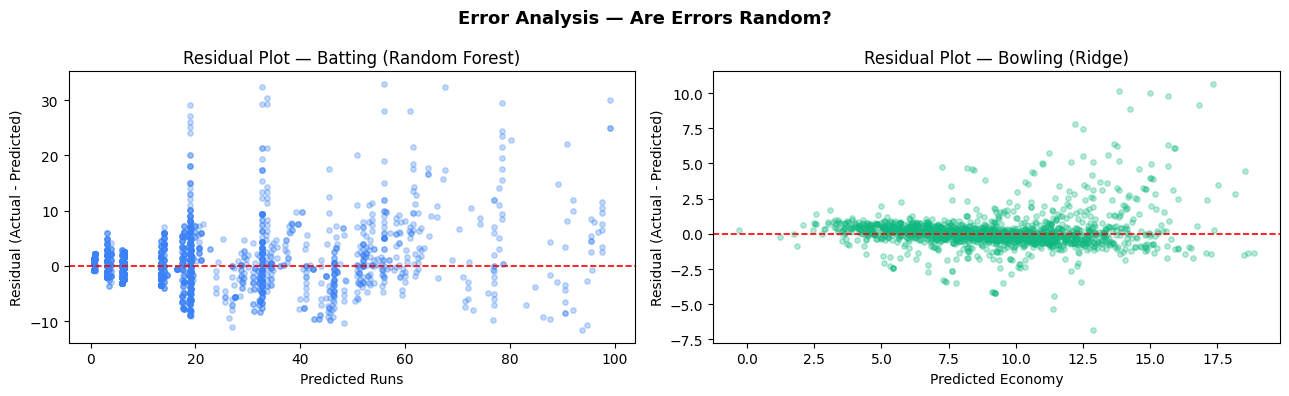


A good model has residuals scattered randomly around zero.
Patterns in residuals suggest the model is missing something.


In [ ]:
# Error Analysis
bat_pred      = rf_bat.predict(X_test_bat)
bat_residuals = y_test_bat - bat_pred

bowl_pred      = ridge_bowl.predict(X_test_bowl)
bowl_residuals = y_test_bowl - bowl_pred

print("=== ERROR ANALYSIS ===\n")
print("BATTING:")
print(f"  Mean residual                 : {bat_residuals.mean():.4f}")
print(f"  Std of residuals              : {bat_residuals.std():.4f}")
print(f"  % predictions within 5 runs  : {(abs(bat_residuals) <= 5).mean()*100:.1f}%")
print(f"  % predictions within 10 runs : {(abs(bat_residuals) <= 10).mean()*100:.1f}%")

print("\nBOWLING:")
print(f"  Mean residual                 : {bowl_residuals.mean():.4f}")
print(f"  Std of residuals              : {bowl_residuals.std():.4f}")
print(f"  % predictions within 1.0 eco : {(abs(bowl_residuals) <= 1.0).mean()*100:.1f}%")
print(f"  % predictions within 2.0 eco : {(abs(bowl_residuals) <= 2.0).mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(bat_pred, bat_residuals,
                alpha=0.3, s=15, color="#3B82F6")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1.2)
axes[0].set_xlabel("Predicted Runs")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residual Plot — Batting (Random Forest)")

axes[1].scatter(bowl_pred, bowl_residuals,
                alpha=0.3, s=15, color="#10B981")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.2)
axes[1].set_xlabel("Predicted Economy")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Plot — Bowling (Ridge)")

plt.suptitle("Error Analysis — Are Errors Random?",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nA good model has residuals scattered randomly around zero.")
print("Patterns in residuals suggest the model is missing something.")

# PART D — DATA VISUALISATION

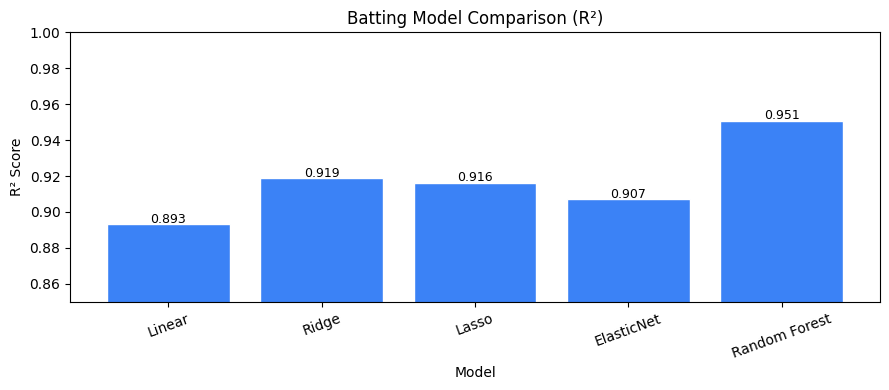

Random Forest achieves the highest R² for batting.
Nonlinear relationships play an important role in predicting batting performance.


In [ ]:
# Batting model comparison chart
models  = ["Linear", "Ridge", "Lasso", "ElasticNet", "Random Forest"]
bat_r2  = [0.8931, 0.9187, 0.9160, 0.9070, 0.9506]

plt.figure(figsize=(9, 4))
bars = plt.bar(models, bat_r2, color="#3B82F6", edgecolor="white")
plt.title("Batting Model Comparison (R²)")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.ylim(0.85, 1.0)
plt.xticks(rotation=20)
for bar, val in zip(bars, bat_r2):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001,
             f"{val:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print("Random Forest achieves the highest R² for batting.")
print("Nonlinear relationships play an important role in predicting batting performance.")

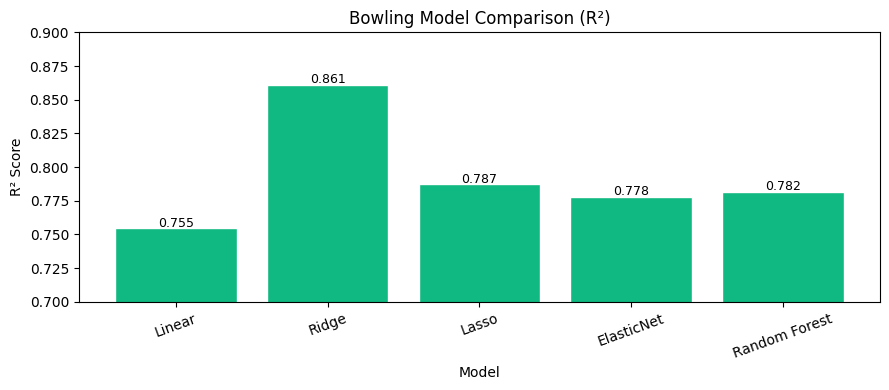

Ridge Regression performs best for bowling.
Simpler regularised models generalise better for noisy bowling data.


In [ ]:
# Bowling model comparison chart
bowl_r2 = [0.7547, 0.8611, 0.7874, 0.7779, 0.7817]

plt.figure(figsize=(9, 4))
bars = plt.bar(models, bowl_r2, color="#10B981", edgecolor="white")
plt.title("Bowling Model Comparison (R²)")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.ylim(0.70, 0.90)
plt.xticks(rotation=20)
for bar, val in zip(bars, bowl_r2):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001,
             f"{val:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print("Ridge Regression performs best for bowling.")
print("Simpler regularised models generalise better for noisy bowling data.")

## Actual vs Predicted — Batting (Random Forest)

This scatter plot compares the actual runs scored against the
model's predicted runs on the test set.

Each point represents one player-match observation from the
2023–2024 test seasons. Points that lie close to the red
diagonal line indicate accurate predictions — the closer
the cluster to the diagonal, the better the model performs.

**Model used:** Random Forest (best performing batting model)
**Dataset:** Test set (seasons 2023–2024, unseen during training)

A strong diagonal cluster confirms that Random Forest has
learned genuine patterns from historical batting data and
generalises well to unseen matches.

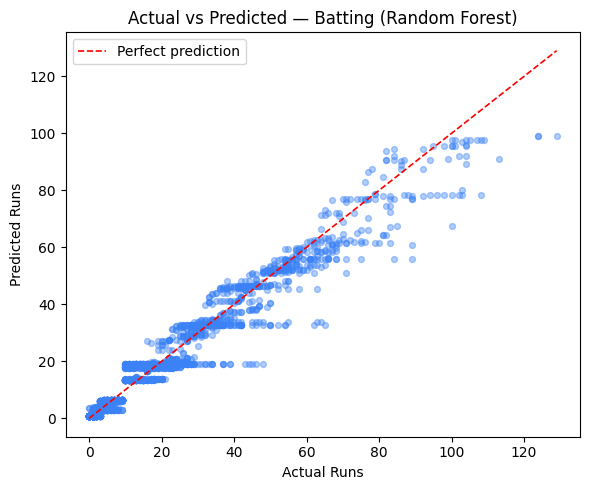

In [ ]:
# Actual vs Predicted — Batting
bat_test_pred = rf_bat.predict(X_test_bat)

plt.figure(figsize=(6, 5))
plt.scatter(y_test_bat, bat_test_pred, alpha=0.4, s=18, color="#3B82F6")
lims = [0, max(y_test_bat.max(), bat_test_pred.max())]
plt.plot(lims, lims, "r--", linewidth=1.2, label="Perfect prediction")
plt.xlabel("Actual Runs")
plt.ylabel("Predicted Runs")
plt.title("Actual vs Predicted — Batting (Random Forest)")
plt.legend()
plt.tight_layout()
plt.show()

## Average Runs by Match Stage

This bar chart shows the average runs scored per innings
across the three match stages in IPL cricket.

**Stage definitions:**
- **League** — regular season matches (baseline)
- **Playoffs** — knockout semi-final matches
- **Final** — the championship match

This visualization is directly aligned with the project's
descriptive objective: understanding how competitive pressure
influences player performance. If playoff and final matches
show different average runs compared to league matches, it
confirms that match stage is a meaningful feature for the
prediction model.

The chart is sorted from lowest to highest average runs
so the stage-based differences are immediately visible.

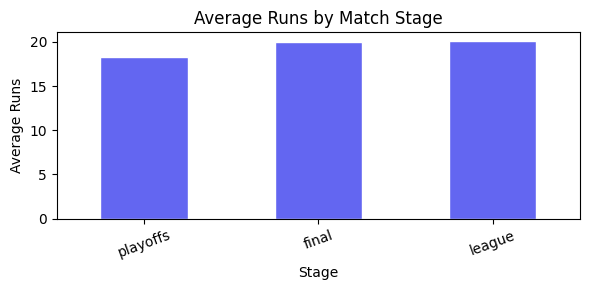

In [ ]:
# Average runs by match stage
pressure = batting_clean.groupby("stage_bucket")["runs"].mean().sort_values()

plt.figure(figsize=(6, 3))
pressure.plot(kind="bar", color="#6366F1", edgecolor="white")
plt.title("Average Runs by Match Stage")
plt.xlabel("Stage")
plt.ylabel("Average Runs")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()



## Feature Importance

**Batting (Random Forest)** — importance based on impurity reduction across all trees.

**Bowling (Ridge)** — importance based on coefficient magnitude.
Positive coefficients increase economy rate; negative coefficients decrease it.

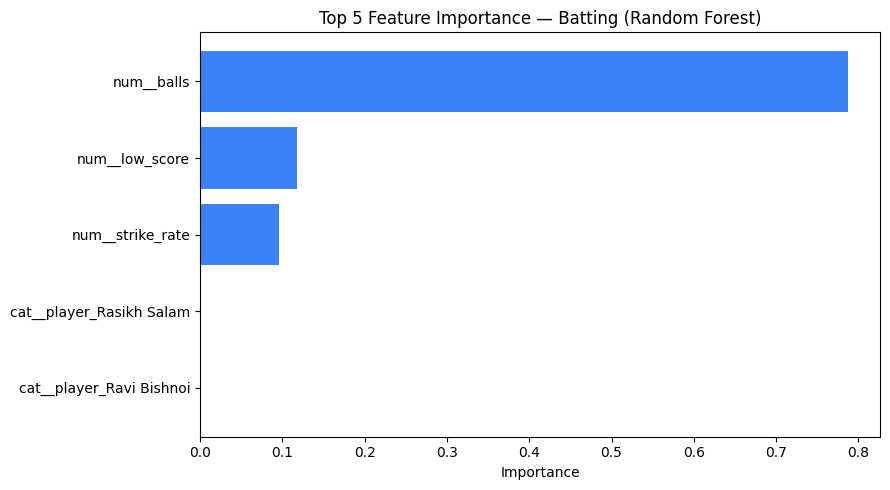

In [ ]:
# Feature importance — Batting
importances   = rf_bat.named_steps["model"].feature_importances_
feature_names = rf_bat.named_steps["preprocess"].get_feature_names_out()

feat_imp = pd.DataFrame({
    "feature":    feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).head(5)

plt.figure(figsize=(9, 5))
plt.barh(feat_imp["feature"], feat_imp["importance"], color="#3B82F6")
plt.title("Top 5 Feature Importance — Batting (Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

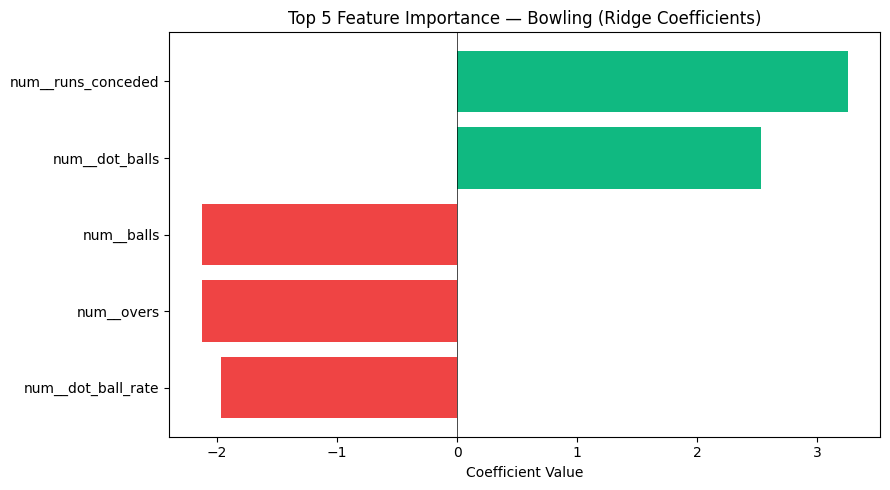

In [ ]:
# Feature importance — Bowling
coefs         = ridge_bowl.named_steps["model"].coef_
feature_names = ridge_bowl.named_steps["preprocess"].get_feature_names_out()

feat_imp_bowl = pd.DataFrame({
    "feature":        feature_names,
    "coefficient":    coefs,
    "abs_importance": np.abs(coefs)
}).sort_values("abs_importance", ascending=False).head(5)

plt.figure(figsize=(9, 5))
colors = [
    "#10B981" if v >= 0 else "#EF4444"
    for v in feat_imp_bowl["coefficient"]
]
plt.barh(feat_imp_bowl["feature"], feat_imp_bowl["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.5)
plt.title("Top 5 Feature Importance — Bowling (Ridge Coefficients)")
plt.xlabel("Coefficient Value")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Player Performance Profile

This function generates a two-panel performance profile for
any individual player in the dataset.

**Left panel — Average Runs by Venue:**
Shows the player's historical average runs at their top venues
(minimum 3 matches required for inclusion). This directly
justifies why venue adjustments are applied in the prediction
system — the same player can perform significantly differently
at different grounds.

**Right panel — Average Runs by Match Stage:**
Shows how the player's average runs differ across league,
playoffs and final matches. This justifies why stage
adjustments are applied on top of the base model prediction.

**Why this matters for the prediction system:**
The prediction functions use both venue and stage adjustments
weighted by the number of historical matches available.
These profiles make those adjustments transparent and
interpretable — the audience can see exactly why a player
is predicted to score more or less in a specific context.

**Examples shown:**
- MS Dhoni — experienced finisher with consistent stage patterns
- Shubman Gill — modern batter with strong playoff record

Players with more historical matches produce more reliable
venue and stage averages, reflected in higher adjustment weights.

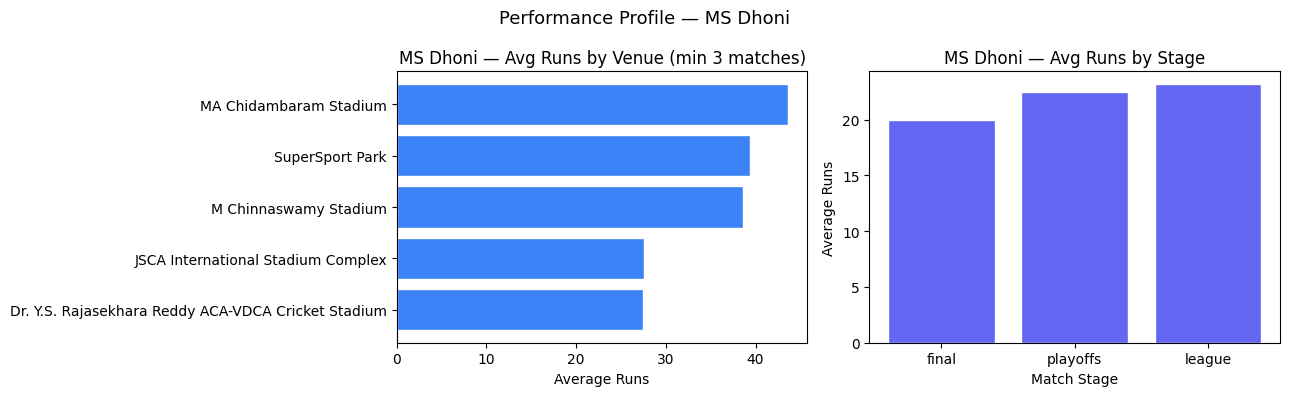

Overall average runs: 23.00
Total matches in dataset: 228


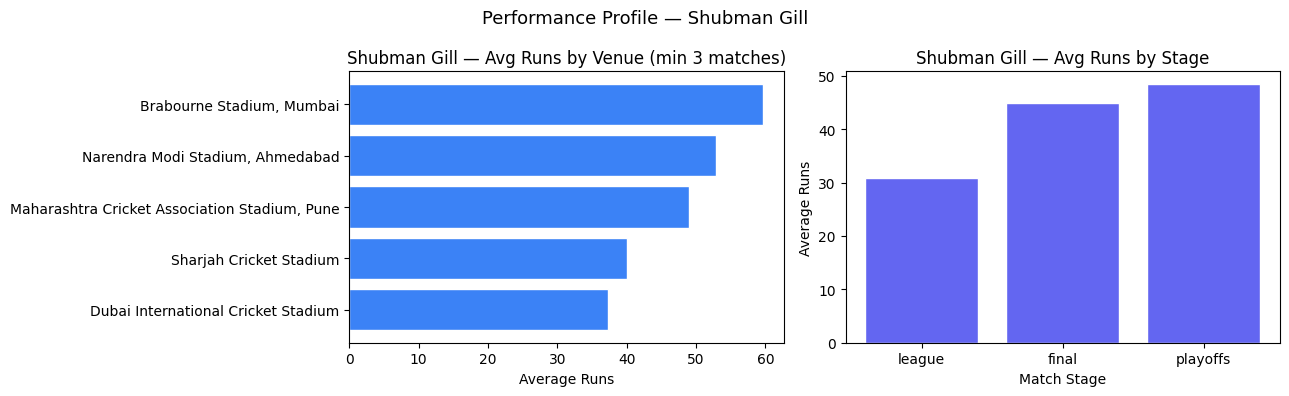

Overall average runs: 32.48
Total matches in dataset: 99


In [ ]:
def plot_player_profile(player_name, top_n_venues=5):
    """
    Show a player's average runs by venue — gives context
    to why venue adjustments matter in the prediction.
    """
    data = batting_clean[batting_clean["player"] == player_name]

    if data.empty:
        print(f"Player {player_name} not found.")
        return

    venue_avg = (
        data.groupby("venue")["runs"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "avg_runs", "count": "matches"})
        .query("matches >= 3")
        .sort_values("avg_runs", ascending=False)
        .head(top_n_venues)
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Venue performance
    axes[0].barh(venue_avg.index, venue_avg["avg_runs"],
                 color="#3B82F6", edgecolor="white")
    axes[0].set_title(f"{player_name} — Avg Runs by Venue (min 3 matches)")
    axes[0].set_xlabel("Average Runs")
    axes[0].invert_yaxis()

    # Stage performance
    stage_avg = data.groupby("stage_bucket")["runs"].mean().sort_values()
    axes[1].bar(stage_avg.index, stage_avg.values,
                color="#6366F1", edgecolor="white")
    axes[1].set_title(f"{player_name} — Avg Runs by Stage")
    axes[1].set_xlabel("Match Stage")
    axes[1].set_ylabel("Average Runs")

    plt.suptitle(f"Performance Profile — {player_name}", fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f"Overall average runs: {data['runs'].mean():.2f}")
    print(f"Total matches in dataset: {len(data)}")

# Example
plot_player_profile("MS Dhoni")
plot_player_profile("Shubman Gill")

## Prediction Sensitivity Analysis

This chart shows how the predicted runs for a player change
across different combinations of venue and match stage.

For each of the player's top 5 venues (by number of matches
played), three bars are shown — one for each match stage:
league, playoffs and final.

**What this reveals:**
- How sensitive predictions are to venue and stage context
- Which venues the player is predicted to perform best at
- Whether the player shows stage-based performance elevation
  (e.g. scoring more in playoffs than league matches)

**How the prediction is calculated:**
Each bar combines three components:
1. Base prediction from the Random Forest model
2. Venue adjustment — weighted by player history at that ground
3. Stage adjustment — weighted by player history at that stage

The weight formula ensures that adjustments are only applied
when sufficient historical data exists (minimum 3 matches)
and are scaled by the number of matches available
(capped at 0.40 for venue and 0.30 for stage).

**Examples shown:**
- MS Dhoni (2024) — shows consistent performance with
  stage-specific variation reflecting his big-match experience
- Shubman Gill (2024) — shows elevated playoff predictions
  consistent with his genuine big-match reputation

This visualization directly validates the prediction system
by showing that predictions respond meaningfully to context
rather than returning the same value for every scenario.

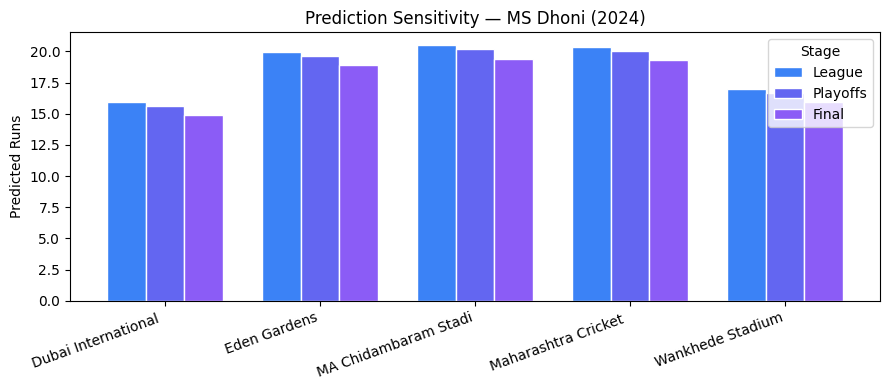

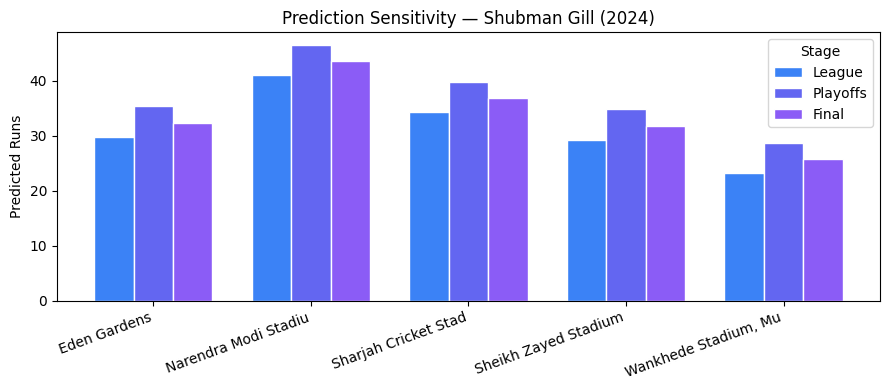

In [ ]:
def plot_prediction_sensitivity(player_name, season="2024"):
    """
    Show how predicted runs change across all stages and
    top venues — makes the adjustment system visible.
    """
    data = batting_clean[
        (batting_clean["player"] == player_name) &
        (batting_clean["season_year"] < int(season))
    ].copy()

    if data.empty:
        print(f"No history for {player_name}.")
        return

    stages = ["league", "playoffs", "final"]
    top_venues = (
        data.groupby("venue")["runs"]
        .count()
        .sort_values(ascending=False)
        .head(5)
        .index.tolist()
    )

    results = []
    for stage in stages:
        for venue in top_venues:
            row = pd.DataFrame(columns=X_train_bat.columns, index=[0])
            for col in X_train_bat.columns:
                if col in data.columns:
                    if pd.api.types.is_numeric_dtype(data[col]):
                        row.loc[0, col] = data[col].mean()
                    else:
                        mode_val = data[col].mode()
                        row.loc[0, col] = mode_val.iloc[0] if not mode_val.empty else np.nan

            if "player"       in row.columns: row.loc[0, "player"]       = player_name
            if "stage_bucket" in row.columns: row.loc[0, "stage_bucket"] = stage
            if "season"       in row.columns: row.loc[0, "season"]       = str(season)
            if "match_year"   in row.columns: row.loc[0, "match_year"]   = int(season)
            if "season_year"  in row.columns: row.loc[0, "season_year"]  = int(season)
            if "match_id"     in row.columns: row.loc[0, "match_id"]     = 0
            if "venue"        in row.columns: row.loc[0, "venue"]        = venue

            overall_avg  = data["runs"].mean()
            venue_data   = data[data["venue"] == venue]
            stage_data   = data[data["stage_bucket"] == stage]

            venue_diff   = (venue_data["runs"].mean() - overall_avg) if len(venue_data) >= 3 else 0
            venue_weight = min(len(venue_data) / 20, 0.4) if len(venue_data) >= 3 else 0
            stage_diff   = (stage_data["runs"].mean() - overall_avg) if len(stage_data) >= 3 else 0
            stage_weight = min(len(stage_data) / 20, 0.3) if len(stage_data) >= 3 else 0

            base   = rf_bat.predict(row)[0]
            final  = max(0, base + venue_diff * venue_weight + stage_diff * stage_weight)
            results.append({"stage": stage, "venue": venue, "prediction": round(final, 2)})

    df_results = pd.DataFrame(results)
    pivot = df_results.pivot(index="venue", columns="stage", values="prediction")

    plt.figure(figsize=(9, 4))
    x = range(len(pivot.index))
    width = 0.25
    colors = ["#3B82F6", "#6366F1", "#8B5CF6"]

    for i, stage in enumerate(stages):
        if stage in pivot.columns:
            plt.bar(
                [xi + i * width for xi in x],
                pivot[stage],
                width=width,
                label=stage.capitalize(),
                color=colors[i],
                edgecolor="white"
            )

    plt.xticks(
        [xi + width for xi in x],
        [v[:20] for v in pivot.index],
        rotation=20, ha="right"
    )
    plt.ylabel("Predicted Runs")
    plt.title(f"Prediction Sensitivity — {player_name} ({season})")
    plt.legend(title="Stage")
    plt.tight_layout()
    plt.show()

plot_prediction_sensitivity("MS Dhoni", "2024")
plot_prediction_sensitivity("Shubman Gill", "2024")

## Season-by-Season Performance Trend

This chart shows how a player's average runs per innings has
changed across every IPL season they have played in.

**What the chart shows:**
- Blue line — average runs scored per match in each season
- Blue shaded area — visual emphasis on performance trend
- Blue dashed line — career average across all seasons
- Purple bars — number of matches played in each season
  (right axis) showing data reliability per season

**Why this matters for the prediction system:**
The prediction model uses historical averages computed from
all prior seasons. This chart gives context to that approach
by showing whether a player is consistent across seasons or
highly variable. A player with stable season averages close
to their career average is more predictable. A player with
large swings between seasons carries more uncertainty.

**The dual axis design:**
Seasons with very few matches (short purple bars) should be
interpreted with caution — a high or low average based on
2 or 3 matches is less reliable than one based on 14 matches.
The match count bars make this uncertainty visible.

**Examples shown:**
- MS Dhoni — long career with consistent late-career patterns
- Shubman Gill — rising trend reflecting his development
  as a top-order batter over recent seasons
- V Kohli — sustained high performance across many seasons
  demonstrating why career averages are strong predictors

This visualization justifies the use of expanding historical
averages as features in the regression models rather than
using only recent or current season statistics.

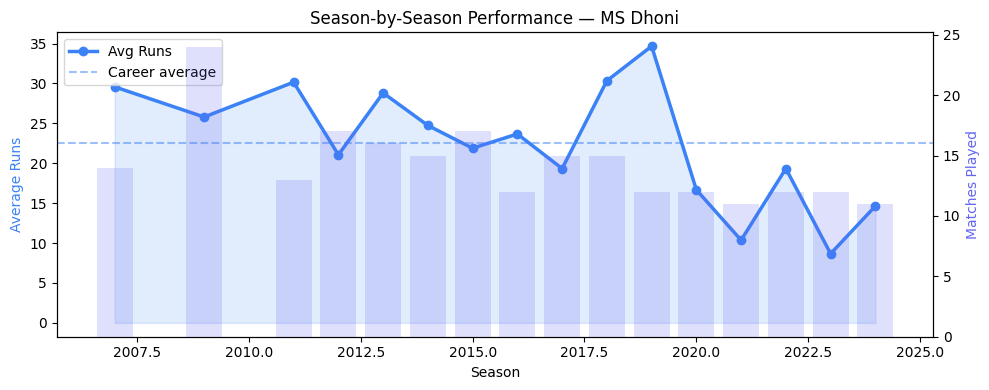

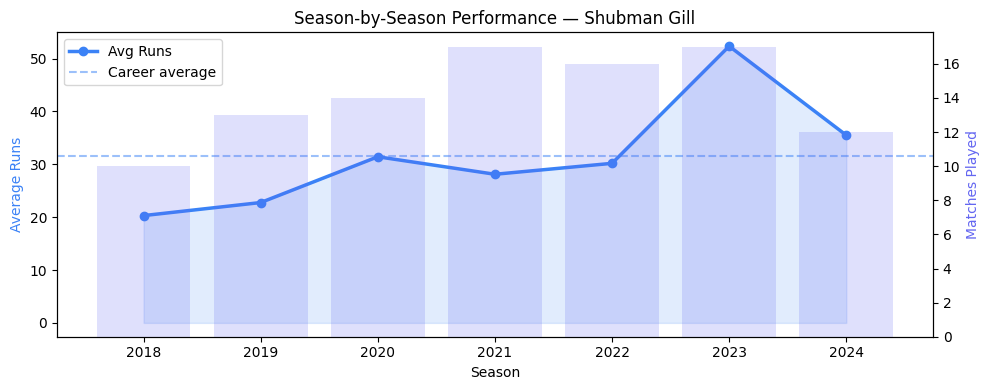

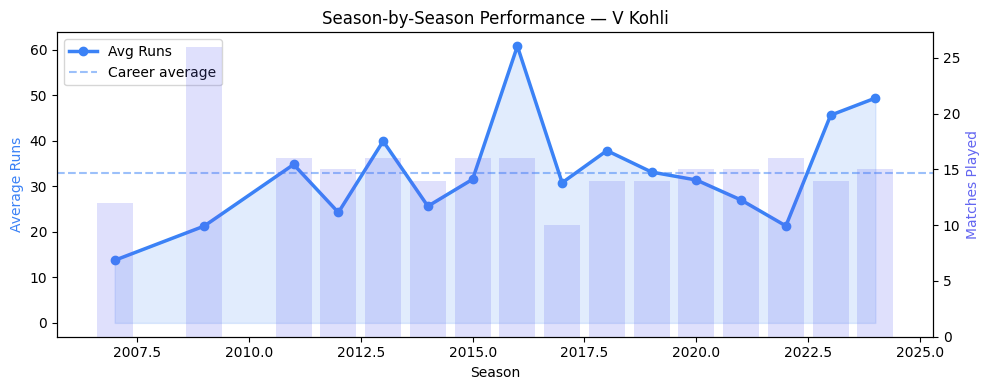

In [ ]:
def plot_season_trend(player_name):
    """
    Show how a player's average runs has changed season by season.
    Gives context to why historical averages are used for prediction.
    """
    data = batting_clean[batting_clean["player"] == player_name]

    if data.empty:
        print(f"Player {player_name} not found.")
        return

    season_avg = (
        data.groupby("season_year")["runs"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "avg_runs", "count": "matches"})
    )

    fig, ax1 = plt.subplots(figsize=(10, 4))

    ax1.plot(season_avg.index, season_avg["avg_runs"],
             color="#3B82F6", linewidth=2.5, marker="o", label="Avg Runs")
    ax1.fill_between(season_avg.index, season_avg["avg_runs"],
                     alpha=0.15, color="#3B82F6")
    ax1.set_xlabel("Season")
    ax1.set_ylabel("Average Runs", color="#3B82F6")
    ax1.axhline(season_avg["avg_runs"].mean(), color="#3B82F6",
                linestyle="--", alpha=0.5, label="Career average")

    ax2 = ax1.twinx()
    ax2.bar(season_avg.index, season_avg["matches"],
            alpha=0.2, color="#6366F1", label="Matches played")
    ax2.set_ylabel("Matches Played", color="#6366F1")

    plt.title(f"Season-by-Season Performance — {player_name}")
    ax1.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

plot_season_trend("MS Dhoni")
plot_season_trend("Shubman Gill")
plot_season_trend("V Kohli")

# PART E — PLAYER PREDICTION FUNCTIONS

These functions predict expected performance for a player in a future match
using only information available **before** the match starts.

**How it works:**
1. The ML model generates a base prediction using the player's historical averages
2. A venue adjustment is applied based on the player's history at that specific ground
3. A stage adjustment is applied based on the player's history at that match stage
4. Final prediction = Base + Venue adjustment + Stage adjustment

**Weight formula:**
- Venue weight = min(matches at venue / 20, 0.40)
- Stage weight = min(matches at stage / 20, 0.30)
- Minimum 3 matches required before any adjustment is applied

In [ ]:
def search_batting_player(player_name, stage="league", season=None,
                           venue=None, match_type=None):
    """
    Predict expected runs for a batter in a future match.

    Parameters
    ----------
    player_name : str  — player name as in the dataset
    stage       : str  — 'league', 'playoffs', or 'final'
    season      : str  — target season e.g. '2024'
    venue       : str  — stadium name (optional)
    match_type  : str  — e.g. 'League', 'Final' (optional)
    """
    if season is None:
        print("Please provide a season.")
        return

    data = batting_clean[
        (batting_clean["player"] == player_name) &
        (batting_clean["season_year"] < int(season))
    ].copy()

    if data.empty:
        print(f"No prior history found for {player_name} before {season}.")
        return

    row = pd.DataFrame(columns=X_train_bat.columns, index=[0])
    for col in X_train_bat.columns:
        if col in data.columns:
            if pd.api.types.is_numeric_dtype(data[col]):
                row.loc[0, col] = data[col].mean()
            else:
                mode_val = data[col].mode()
                row.loc[0, col] = (
                    mode_val.iloc[0] if not mode_val.empty else np.nan
                )

    if "player"       in row.columns: row.loc[0, "player"]       = player_name
    if "stage_bucket" in row.columns: row.loc[0, "stage_bucket"] = stage
    if "season"       in row.columns: row.loc[0, "season"]       = str(season)
    if "match_year"   in row.columns: row.loc[0, "match_year"]   = int(season)
    if "season_year"  in row.columns: row.loc[0, "season_year"]  = int(season)
    if "match_id"     in row.columns: row.loc[0, "match_id"]     = 0
    if venue is not None and "venue" in row.columns:
        row.loc[0, "venue"] = venue
    if match_type is not None and "match_type" in row.columns:
        row.loc[0, "match_type"] = match_type

    overall_avg = data["runs"].mean()

    # Venue adjustment
    venue_data = data[data["venue"] == venue] if venue else pd.DataFrame()
    if len(venue_data) >= 3:
        venue_avg    = venue_data["runs"].mean()
        venue_diff   = venue_avg - overall_avg
        venue_weight = min(len(venue_data) / 20, 0.4)
        print(f"Venue  : {venue} ({len(venue_data)} matches)")
        print(f"  Overall avg : {overall_avg:.2f} | "
              f"Venue avg : {venue_avg:.2f} | Diff : {venue_diff:+.2f}")
    else:
        venue_diff, venue_weight = 0, 0
        print(f"Venue  : limited history at {venue} — no venue adjustment")

    # Stage adjustment
    stage_data = data[data["stage_bucket"] == stage] if stage else pd.DataFrame()
    if len(stage_data) >= 3:
        stage_avg    = stage_data["runs"].mean()
        stage_diff   = stage_avg - overall_avg
        stage_weight = min(len(stage_data) / 20, 0.3)
        print(f"Stage  : {stage} ({len(stage_data)} matches)")
        print(f"  Overall avg : {overall_avg:.2f} | "
              f"Stage avg  : {stage_avg:.2f} | Diff : {stage_diff:+.2f}")
    else:
        stage_diff, stage_weight = 0, 0
        print(f"Stage  : limited history for {stage} — no stage adjustment")

    base_prediction     = rf_bat.predict(row)[0]
    venue_adjustment    = venue_diff * venue_weight
    stage_adjustment    = stage_diff * stage_weight
    adjusted_prediction = max(0, base_prediction + venue_adjustment + stage_adjustment)

    years = [int(y) for y in sorted(data["season_year"].unique())]

    print(f"\n{'='*45}")
    print(f"Player             : {player_name}")
    print(f"Venue              : {venue}")
    print(f"Stage              : {stage}")
    print(f"Season             : {season}")
    print(f"{'='*45}")
    print(f"Base prediction    : {base_prediction:.2f} runs")
    print(f"Venue adjustment   : {venue_adjustment:+.2f} runs")
    print(f"Stage adjustment   : {stage_adjustment:+.2f} runs")
    print(f"{'─'*45}")
    print(f"Final prediction   : {adjusted_prediction:.2f} runs")
    print(f"{'='*45}")
    print(f"Years of history   : {years}")

In [ ]:
def search_bowling_player(player_name, stage="league", season=None,
                           venue=None, match_type=None):
    """
    Predict expected economy rate for a bowler in a future match.

    Parameters
    ----------
    player_name : str  — bowler name as in the dataset
    stage       : str  — 'league', 'playoffs', or 'final'
    season      : str  — target season e.g. '2024'
    venue       : str  — stadium name (optional)
    match_type  : str  — e.g. 'League', 'Final' (optional)
    """
    if season is None:
        print("Please provide a season.")
        return

    data = bowling_clean[
        (bowling_clean["bowler"] == player_name) &
        (bowling_clean["season_year"] < int(season))
    ].copy()

    if data.empty:
        print(f"No prior history found for {player_name} before {season}.")
        return

    row = pd.DataFrame(columns=X_train_bowl.columns, index=[0])
    for col in X_train_bowl.columns:
        if col in data.columns:
            if pd.api.types.is_numeric_dtype(data[col]):
                row.loc[0, col] = data[col].mean()
            else:
                mode_val = data[col].mode()
                row.loc[0, col] = (
                    mode_val.iloc[0] if not mode_val.empty else np.nan
                )

    if "bowler"       in row.columns: row.loc[0, "bowler"]       = player_name
    if "stage_bucket" in row.columns: row.loc[0, "stage_bucket"] = stage
    if "season"       in row.columns: row.loc[0, "season"]       = str(season)
    if "match_year"   in row.columns: row.loc[0, "match_year"]   = int(season)
    if "season_year"  in row.columns: row.loc[0, "season_year"]  = int(season)
    if "match_id"     in row.columns: row.loc[0, "match_id"]     = 0
    if venue is not None and "venue" in row.columns:
        row.loc[0, "venue"] = venue
    if match_type is not None and "match_type" in row.columns:
        row.loc[0, "match_type"] = match_type

    overall_avg = data["economy"].mean()

    # Venue adjustment
    venue_data = data[data["venue"] == venue] if venue else pd.DataFrame()
    if len(venue_data) >= 3:
        venue_avg    = venue_data["economy"].mean()
        venue_diff   = venue_avg - overall_avg
        venue_weight = min(len(venue_data) / 20, 0.4)
        print(f"Venue  : {venue} ({len(venue_data)} matches)")
        print(f"  Overall avg : {overall_avg:.2f} | "
              f"Venue avg : {venue_avg:.2f} | Diff : {venue_diff:+.2f}")
    else:
        venue_diff, venue_weight = 0, 0
        print(f"Venue  : limited history at {venue} — no venue adjustment")

    # Stage adjustment
    stage_data = data[data["stage_bucket"] == stage] if stage else pd.DataFrame()
    if len(stage_data) >= 3:
        stage_avg    = stage_data["economy"].mean()
        stage_diff   = stage_avg - overall_avg
        stage_weight = min(len(stage_data) / 20, 0.3)
        print(f"Stage  : {stage} ({len(stage_data)} matches)")
        print(f"  Overall avg : {overall_avg:.2f} | "
              f"Stage avg  : {stage_avg:.2f} | Diff : {stage_diff:+.2f}")
    else:
        stage_diff, stage_weight = 0, 0
        print(f"Stage  : limited history for {stage} — no stage adjustment")

    base_prediction     = ridge_bowl.predict(row)[0]
    venue_adjustment    = venue_diff * venue_weight
    stage_adjustment    = stage_diff * stage_weight
    adjusted_prediction = max(0, base_prediction + venue_adjustment + stage_adjustment)

    years = [int(y) for y in sorted(data["season_year"].unique())]

    print(f"\n{'='*45}")
    print(f"Bowler             : {player_name}")
    print(f"Venue              : {venue}")
    print(f"Stage              : {stage}")
    print(f"Season             : {season}")
    print(f"{'='*45}")
    print(f"Base prediction    : {base_prediction:.2f} economy")
    print(f"Venue adjustment   : {venue_adjustment:+.2f}")
    print(f"Stage adjustment   : {stage_adjustment:+.2f}")
    print(f"{'─'*45}")
    print(f"Final prediction   : {adjusted_prediction:.2f} economy")
    print(f"{'='*45}")
    print(f"Years of history   : {years}")



## Example Predictions

Testing the prediction functions with well-known IPL players
across different venues and match stages.


## Example Predictions

Testing the prediction functions with well-known IPL players
across different venues and match stages.

In [ ]:
print("=" * 55)
print("BATTING — MS Dhoni across different contexts")
print("=" * 55)

search_batting_player(
    player_name="MS Dhoni",
    stage="league",
    season="2024",
    venue="Narendra Modi Stadium",
    match_type="League"
)
print()
search_batting_player(
    player_name="MS Dhoni",
    stage="final",
    season="2024",
    venue="Wankhede Stadium",
    match_type="Final"
)
print()
search_batting_player(
    player_name="MS Dhoni",
    stage="playoffs",
    season="2024",
    venue="Eden Gardens",
    match_type="Semi Final"
)

BATTING — MS Dhoni across different contexts
Venue  : limited history at Narendra Modi Stadium — no venue adjustment
Stage  : league (195 matches)
  Overall avg : 23.42 | Stage avg  : 23.64 | Diff : +0.22

Player             : MS Dhoni
Venue              : Narendra Modi Stadium
Stage              : league
Season             : 2024
Base prediction    : 19.15 runs
Venue adjustment   : +0.00 runs
Stage adjustment   : +0.07 runs
─────────────────────────────────────────────
Final prediction   : 19.22 runs
Years of history   : [2007, 2009, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]

Venue  : Wankhede Stadium (14 matches)
  Overall avg : 23.42 | Venue avg : 17.86 | Diff : -5.56
Stage  : final (9 matches)
  Overall avg : 23.42 | Stage avg  : 20.00 | Diff : -3.42

Player             : MS Dhoni
Venue              : Wankhede Stadium
Stage              : final
Season             : 2024
Base prediction    : 19.15 runs
Venue adjustment   : -2.22 runs
Stage adjustm

In [ ]:
print("=" * 55)
print("BATTING — Shubman Gill across different contexts")
print("=" * 55)

search_batting_player(
    player_name="Shubman Gill",
    stage="league",
    season="2024",
    venue="Narendra Modi Stadium",
    match_type="League"
)
print()
search_batting_player(
    player_name="Shubman Gill",
    stage="playoffs",
    season="2024",
    venue="Narendra Modi Stadium",
    match_type="Semi Final"
)
print()
search_batting_player(
    player_name="Shubman Gill",
    stage="final",
    season="2024",
    venue="Narendra Modi Stadium",
    match_type="Final"
)

BATTING — Shubman Gill across different contexts
Venue  : limited history at Narendra Modi Stadium — no venue adjustment
Stage  : league (77 matches)
  Overall avg : 32.07 | Stage avg  : 30.08 | Diff : -1.99

Player             : Shubman Gill
Venue              : Narendra Modi Stadium
Stage              : league
Season             : 2024
Base prediction    : 32.13 runs
Venue adjustment   : +0.00 runs
Stage adjustment   : -0.60 runs
─────────────────────────────────────────────
Final prediction   : 31.53 runs
Years of history   : [2018, 2019, 2020, 2021, 2022, 2023]

Venue  : limited history at Narendra Modi Stadium — no venue adjustment
Stage  : playoffs (7 matches)
  Overall avg : 32.07 | Stage avg  : 48.43 | Diff : +16.36

Player             : Shubman Gill
Venue              : Narendra Modi Stadium
Stage              : playoffs
Season             : 2024
Base prediction    : 32.13 runs
Venue adjustment   : +0.00 runs
Stage adjustment   : +4.91 runs
────────────────────────────────────

In [ ]:
print("=" * 55)
print("BOWLING — JJ Bumrah across different contexts")
print("=" * 55)

search_bowling_player(
    player_name="JJ Bumrah",
    stage="league",
    season="2024",
    venue="Wankhede Stadium",
    match_type="League"
)
print()
search_bowling_player(
    player_name="JJ Bumrah",
    stage="final",
    season="2024",
    venue="Narendra Modi Stadium",
    match_type="Final"
)
print()
search_bowling_player(
    player_name="JJ Bumrah",
    stage="playoffs",
    season="2024",
    venue="Eden Gardens",
    match_type="Semi Final"
)


BOWLING — JJ Bumrah across different contexts
Venue  : Wankhede Stadium (32 matches)
  Overall avg : 7.31 | Venue avg : 7.86 | Diff : +0.54
Stage  : league (112 matches)
  Overall avg : 7.31 | Stage avg  : 7.38 | Diff : +0.07

Bowler             : JJ Bumrah
Venue              : Wankhede Stadium
Stage              : league
Season             : 2024
Base prediction    : 7.31 economy
Venue adjustment   : +0.22
Stage adjustment   : +0.02
─────────────────────────────────────────────
Final prediction   : 7.55 economy
Years of history   : [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

Venue  : limited history at Narendra Modi Stadium — no venue adjustment
Stage  : final (3 matches)
  Overall avg : 7.31 | Stage avg  : 6.25 | Diff : -1.06

Bowler             : JJ Bumrah
Venue              : Narendra Modi Stadium
Stage              : final
Season             : 2024
Base prediction    : 7.21 economy
Venue adjustment   : +0.00
Stage adjustment   : -0.16
────────────────────────────

## Dashboard Summary

This dashboard presents the results of an IPL cricket performance
prediction project built using machine learning. It covers the full
pipeline from raw match data to trained models and interactive
predictions.

### What You Will Learn

1. **Model Performance** — Which of the five models (Linear, Ridge,
   Lasso, Elastic Net, Random Forest) performs best for predicting
   batting runs and bowling economy rate, and by how much each
   improves over the baseline.

2. **Feature Importance** — Which features drive predictions most
   strongly. For batting, balls faced and strike rate dominate.
   For bowling, runs conceded and dot ball rate are most influential.

3. **Prediction Accuracy** — How closely model predictions match
   actual match outcomes. Batting predictions are off by roughly
   4 runs on average. Bowling predictions are off by about 1
   economy point on average.

4. **Match Stage Analysis** — How average batting and bowling
   performance differs across league matches, playoffs and finals.

5. **Player Rankings** — Who the top performing batters and bowlers
   are at any venue, season and match type — filterable interactively.

6. **Player Prediction** — What any player is predicted to score
   or concede at a specific venue and match stage, with a full
   breakdown of base prediction plus venue and stage adjustments.

### Key Finding

Batting performance is reliably predictable from historical data
(R² = 0.95 using Random Forest). Bowling economy is harder to
predict because match-day factors like pitch conditions, weather
and opposition form are not captured in historical statistics alone.
Ridge Regression performs best for bowling (R² = 0.86).

### How to Use This Dashboard

Use the tab buttons at the top to switch between views.
In the Player Rankings tab use the dropdowns to filter by venue,
season and match type. In the Player Prediction tab type any
player name and select a venue, stage and season to generate
a prediction.


## Interactive Prediction Widgets

Use the dropdowns below to search for any player and get
a predicted performance for any venue, stage and season.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

batting_players  = sorted(batting_clean["player"].dropna().unique().tolist())
venues_bat       = sorted(batting_clean["venue"].dropna().unique().tolist())
match_types_bat  = sorted(batting_clean["match_type"].dropna().unique().tolist())

player_dropdown_bat = widgets.Combobox(
    placeholder="Type batter name",
    options=batting_players,
    description="Batter:",
    ensure_option=False,
    layout=widgets.Layout(width="400px")
)
stage_dropdown_bat = widgets.Dropdown(
    options=["league", "playoffs", "final"],
    value="league",
    description="Stage:"
)
season_dropdown_bat = widgets.Dropdown(
    options=[str(y) for y in range(2018, 2025)],
    value="2024",
    description="Season:"
)
venue_dropdown_bat = widgets.Dropdown(
    options=venues_bat,
    description="Venue:",
    layout=widgets.Layout(width="400px")
)
match_type_dropdown_bat = widgets.Dropdown(
    options=match_types_bat,
    description="Type:"
)
predict_button_bat = widgets.Button(
    description="Predict Runs",
    button_style="success"
)
output_bat = widgets.Output()

def on_predict_bat_clicked(b):
    with output_bat:
        clear_output()
        search_batting_player(
            player_name=player_dropdown_bat.value,
            stage=stage_dropdown_bat.value,
            season=season_dropdown_bat.value,
            venue=venue_dropdown_bat.value,
            match_type=match_type_dropdown_bat.value
        )

predict_button_bat.on_click(on_predict_bat_clicked)

display(widgets.VBox([
    widgets.HTML("<h3>Batting Prediction Search</h3>"),
    player_dropdown_bat,
    stage_dropdown_bat,
    season_dropdown_bat,
    venue_dropdown_bat,
    match_type_dropdown_bat,
    predict_button_bat,
    output_bat
]))

In [ ]:
bowling_players  = sorted(bowling_clean["bowler"].dropna().unique().tolist())
venues_bowl      = sorted(bowling_clean["venue"].dropna().unique().tolist())
match_types_bowl = sorted(bowling_clean["match_type"].dropna().unique().tolist())

player_dropdown_bowl = widgets.Combobox(
    placeholder="Type bowler name",
    options=bowling_players,
    description="Bowler:",
    ensure_option=False,
    layout=widgets.Layout(width="400px")
)
stage_dropdown_bowl = widgets.Dropdown(
    options=["league", "playoffs", "final"],
    value="league",
    description="Stage:"
)
season_dropdown_bowl = widgets.Dropdown(
    options=[str(y) for y in range(2018, 2025)],
    value="2024",
    description="Season:"
)
venue_dropdown_bowl = widgets.Dropdown(
    options=venues_bowl,
    description="Venue:",
    layout=widgets.Layout(width="400px")
)
match_type_dropdown_bowl = widgets.Dropdown(
    options=match_types_bowl,
    description="Type:"
)
predict_button_bowl = widgets.Button(
    description="Predict Economy",
    button_style="info"
)
output_bowl = widgets.Output()

def on_predict_bowl_clicked(b):
    with output_bowl:
        clear_output()
        search_bowling_player(
            player_name=player_dropdown_bowl.value,
            stage=stage_dropdown_bowl.value,
            season=season_dropdown_bowl.value,
            venue=venue_dropdown_bowl.value,
            match_type=match_type_dropdown_bowl.value
        )

predict_button_bowl.on_click(on_predict_bowl_clicked)

display(widgets.VBox([
    widgets.HTML("<h3>Bowling Prediction Search</h3>"),
    player_dropdown_bowl,
    stage_dropdown_bowl,
    season_dropdown_bowl,
    venue_dropdown_bowl,
    match_type_dropdown_bowl,
    predict_button_bowl,
    output_bowl
]))



## Dashboard — IPL Cricket Performance Prediction

### What You Will Learn From This Dashboard

This dashboard presents the results of a machine learning project
that predicts IPL cricket player performance before a match starts.

**Tab 1 — Model Performance**
Compare three regression models (Linear, Ridge, Lasso) for both
batting and bowling tasks. Ridge Regression performs best for both.

**Tab 2 — Feature Importance**
Understand which features drive predictions most strongly.
For batting, balls faced and strike rate dominate.
For bowling, runs conceded and dot ball rate are most influential.

**Tab 3 — Actual vs Predicted**
Visualise how closely model predictions match real match outcomes.
Points close to the red diagonal line indicate accurate predictions.

**Tab 4 — Player Prediction**
Enter any player name, venue, stage and season to get a predicted
performance with a breakdown of base prediction plus context adjustments.

### Key Finding
Batting performance is moderately predictable from historical data
(R² ~ 0.90). Bowling economy is harder to predict because match-day
factors like pitch conditions and opposition form are not captured
in historical statistics.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ── Map variable names ─────────────────────────────────────────────────────
bat_linear  = bat_model
bat_ridge   = ridge_bat
bat_lasso   = lasso_bat
bat_elastic = elastic_bat
bat_rf      = rf_bat

bowl_linear  = bowl_model
bowl_ridge   = ridge_bowl
bowl_lasso   = lasso_bowl
bowl_elastic = elastic_bowl
bowl_rf      = rf_bowl

# ══════════════════════════════════════════════════════════════════════════
# DASHBOARD VIEW FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════

def show_model_performance():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.subplots_adjust(wspace=0.35)

    models = ["Linear", "Ridge", "Lasso", "ElasticNet", "Random Forest"]
    bat_r2 = [
        r2_score(y_test_bat, bat_linear.predict(X_test_bat)),
        r2_score(y_test_bat, bat_ridge.predict(X_test_bat)),
        r2_score(y_test_bat, bat_lasso.predict(X_test_bat)),
        r2_score(y_test_bat, bat_elastic.predict(X_test_bat)),
        r2_score(y_test_bat, bat_rf.predict(X_test_bat)),
    ]
    bowl_r2 = [
        r2_score(y_test_bowl, bowl_linear.predict(X_test_bowl)),
        r2_score(y_test_bowl, bowl_ridge.predict(X_test_bowl)),
        r2_score(y_test_bowl, bowl_lasso.predict(X_test_bowl)),
        r2_score(y_test_bowl, bowl_elastic.predict(X_test_bowl)),
        r2_score(y_test_bowl, bowl_rf.predict(X_test_bowl)),
    ]

    bat_colors  = ["#3B82F6" if v == max(bat_r2) else "#BFDBFE" for v in bat_r2]
    bowl_colors = ["#10B981" if v == max(bowl_r2) else "#A7F3D0" for v in bowl_r2]

    bars1 = axes[0].bar(models, bat_r2, color=bat_colors,
                        edgecolor="white", width=0.5)
    axes[0].set_title("Batting — Model Comparison (Test R²)",
                      fontsize=13, pad=15)
    axes[0].set_ylabel("R² Score", fontsize=11)
    axes[0].set_ylim(max(0, min(bat_r2) - 0.08), 1.0)
    axes[0].tick_params(axis="x", rotation=25, labelsize=10)
    axes[0].tick_params(axis="y", labelsize=10)
    for bar, val in zip(bars1, bat_r2):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.003,
                     f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")

    bars2 = axes[1].bar(models, bowl_r2, color=bowl_colors,
                        edgecolor="white", width=0.5)
    axes[1].set_title("Bowling — Model Comparison (Test R²)",
                      fontsize=13, pad=15)
    axes[1].set_ylabel("R² Score", fontsize=11)
    axes[1].set_ylim(max(0, min(bowl_r2) - 0.08), 1.0)
    axes[1].tick_params(axis="x", rotation=25, labelsize=10)
    axes[1].tick_params(axis="y", labelsize=10)
    for bar, val in zip(bars2, bowl_r2):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.003,
                     f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")

    plt.suptitle("Model Performance Overview", fontsize=15,
                 fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    best_bat  = models[bat_r2.index(max(bat_r2))]
    best_bowl = models[bowl_r2.index(max(bowl_r2))]
    print(f"\n  Best Batting model : {best_bat} (R² = {max(bat_r2):.4f})")
    print(f"  Best Bowling model : {best_bowl} (R² = {max(bowl_r2):.4f})")
    print(f"\n  Improvement over Linear baseline:")
    print(f"    Batting  : +{max(bat_r2) - bat_r2[0]:.4f}")
    print(f"    Bowling  : +{max(bowl_r2) - bowl_r2[0]:.4f}")


def show_feature_importance():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.subplots_adjust(wspace=0.5)

    importances = bat_rf.named_steps["model"].feature_importances_
    feat_names  = bat_rf.named_steps["preprocess"].get_feature_names_out()
    fi_bat = pd.DataFrame({
        "feature":    feat_names,
        "importance": importances
    }).sort_values("importance", ascending=False).head(10)

    colors_bat = ["#1D4ED8" if i == 0 else "#3B82F6" if i < 3 else "#BFDBFE"
                  for i in range(len(fi_bat))]
    axes[0].barh(fi_bat["feature"], fi_bat["importance"],
                 color=colors_bat, edgecolor="white", height=0.6)
    axes[0].set_title("Top 10 Features — Batting\n(Random Forest Importance)",
                      fontsize=12, pad=15)
    axes[0].set_xlabel("Importance Score", fontsize=11)
    axes[0].tick_params(axis="y", labelsize=9)
    axes[0].invert_yaxis()

    coefs_bowl      = bowl_ridge.named_steps["model"].coef_
    feat_names_bowl = bowl_ridge.named_steps["preprocess"].get_feature_names_out()
    fi_bowl = pd.DataFrame({
        "feature":        feat_names_bowl,
        "coefficient":    coefs_bowl,
        "abs_importance": np.abs(coefs_bowl)
    }).sort_values("abs_importance", ascending=False).head(10)

    colors_bowl = [
        "#10B981" if v >= 0 else "#EF4444"
        for v in fi_bowl["coefficient"]
    ]
    axes[1].barh(fi_bowl["feature"], fi_bowl["coefficient"],
                 color=colors_bowl, edgecolor="white", height=0.6)
    axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
    axes[1].set_title("Top 10 Features — Bowling\n(Ridge Coefficients)",
                      fontsize=12, pad=15)
    axes[1].set_xlabel("Coefficient Value", fontsize=11)
    axes[1].tick_params(axis="y", labelsize=9)
    axes[1].invert_yaxis()

    plt.suptitle("Feature Importance Analysis", fontsize=15,
                 fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    print("\n  Batting : Darker blue = stronger predictor")
    print("  Bowling : Green = increases economy | Red = decreases economy")


def show_actual_vs_predicted():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.subplots_adjust(wspace=0.35)

    bat_pred  = bat_rf.predict(X_test_bat)
    bowl_pred = bowl_ridge.predict(X_test_bowl)

    axes[0].scatter(y_test_bat, bat_pred,
                    alpha=0.4, s=25, color="#3B82F6", edgecolors="none")
    lims = [0, max(y_test_bat.max(), bat_pred.max())]
    axes[0].plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
    axes[0].set_xlabel("Actual Runs", fontsize=11)
    axes[0].set_ylabel("Predicted Runs", fontsize=11)
    axes[0].set_title("Actual vs Predicted — Batting\n(Random Forest)",
                      fontsize=12, pad=15)
    axes[0].legend(fontsize=10)
    axes[0].tick_params(labelsize=10)

    axes[1].scatter(y_test_bowl, bowl_pred,
                    alpha=0.4, s=25, color="#10B981", edgecolors="none")
    lims2 = [0, max(y_test_bowl.max(), bowl_pred.max())]
    axes[1].plot(lims2, lims2, "r--", linewidth=1.5, label="Perfect prediction")
    axes[1].set_xlabel("Actual Economy", fontsize=11)
    axes[1].set_ylabel("Predicted Economy", fontsize=11)
    axes[1].set_title("Actual vs Predicted — Bowling\n(Ridge Regression)",
                      fontsize=12, pad=15)
    axes[1].legend(fontsize=10)
    axes[1].tick_params(labelsize=10)

    plt.suptitle("Prediction Accuracy", fontsize=15,
                 fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    bat_mae  = mean_absolute_error(y_test_bat,  bat_pred)
    bat_r2   = r2_score(y_test_bat,  bat_pred)
    bowl_mae = mean_absolute_error(y_test_bowl, bowl_pred)
    bowl_r2  = r2_score(y_test_bowl, bowl_pred)

    print(f"\n  Batting  — MAE: {bat_mae:.2f} runs       | R²: {bat_r2:.4f}")
    print(f"  Bowling  — MAE: {bowl_mae:.2f} economy   | R²: {bowl_r2:.4f}")
    print(f"\n  Batting predictions are off by ~{bat_mae:.0f} runs on average.")
    print(f"  Bowling predictions are off by ~{bowl_mae:.1f} economy points on average.")


def show_stage_analysis():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.subplots_adjust(wspace=0.4)

    stage_bat  = batting_clean.groupby("stage_bucket")["runs"].mean().sort_values(ascending=False)
    stage_bowl = bowling_clean.groupby("stage_bucket")["economy"].mean().sort_values(ascending=False)

    colors_bat  = ["#1D4ED8" if i == 0 else "#3B82F6" if i == 1 else "#BFDBFE"
                   for i in range(len(stage_bat))]
    colors_bowl = ["#065F46" if i == 0 else "#10B981" if i == 1 else "#A7F3D0"
                   for i in range(len(stage_bowl))]

    bars1 = axes[0].bar(stage_bat.index, stage_bat.values,
                        color=colors_bat, edgecolor="white", width=0.4)
    axes[0].set_title("Average Runs by Match Stage\n(Highest to Lowest)",
                      fontsize=12, pad=15)
    axes[0].set_ylabel("Average Runs", fontsize=11)
    axes[0].tick_params(axis="x", rotation=15, labelsize=10)
    axes[0].tick_params(axis="y", labelsize=10)
    for bar, val in zip(bars1, stage_bat.values):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.1,
                     f"{val:.1f}", ha="center", fontsize=10, fontweight="bold")

    bars2 = axes[1].bar(stage_bowl.index, stage_bowl.values,
                        color=colors_bowl, edgecolor="white", width=0.4)
    axes[1].set_title("Average Economy by Match Stage\n(Highest to Lowest)",
                      fontsize=12, pad=15)
    axes[1].set_ylabel("Average Economy Rate", fontsize=11)
    axes[1].tick_params(axis="x", rotation=15, labelsize=10)
    axes[1].tick_params(axis="y", labelsize=10)
    for bar, val in zip(bars2, stage_bowl.values):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.02,
                     f"{val:.2f}", ha="center", fontsize=10, fontweight="bold")

    plt.suptitle("Performance by Match Stage", fontsize=15,
                 fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    print("\n  Darker colour = highest performing stage")


# ── Player Rankings ────────────────────────────────────────────────────────
def show_player_rankings(venue_filter, season_filter, type_filter):
    fig, axes = plt.subplots(1, 2, figsize=(14, 8))
    fig.subplots_adjust(wspace=0.6)

    # ── Filter batting ─────────────────────────────────────────────────────
    bat_data = batting_clean.copy()
    if venue_filter != "All Venues":
        bat_data = bat_data[bat_data["venue"] == venue_filter]
    if season_filter != "All Seasons":
        bat_data = bat_data[bat_data["season_year"] == int(season_filter)]
    if type_filter != "All Types":
        bat_data = bat_data[bat_data["match_type"] == type_filter]

    top_bat = (
        bat_data.groupby("player")["runs"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "avg_runs", "count": "matches"})
        .query("matches >= 1")
        .sort_values("avg_runs", ascending=False)
        .head(10)
        .reset_index()
    )

    # ── Filter bowling ─────────────────────────────────────────────────────
    bowl_data = bowling_clean.copy()
    if venue_filter != "All Venues":
        bowl_data = bowl_data[bowl_data["venue"] == venue_filter]
    if season_filter != "All Seasons":
        bowl_data = bowl_data[bowl_data["season_year"] == int(season_filter)]
    if type_filter != "All Types":
        bowl_data = bowl_data[bowl_data["match_type"] == type_filter]

    top_bowl = (
        bowl_data.groupby("bowler")["economy"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "avg_economy", "count": "matches"})
        .query("matches >= 1")
        .sort_values("avg_economy", ascending=True)
        .head(10)
        .reset_index()
    )

    # ── Batting chart ──────────────────────────────────────────────────────
    if len(top_bat) > 0:
        colors_bat = [
            "#1D4ED8" if i == 0 else
            "#3B82F6" if i == 1 else
            "#60A5FA" if i == 2 else
            "#BFDBFE"
            for i in range(len(top_bat))
        ]
        bars1 = axes[0].barh(
            top_bat["player"], top_bat["avg_runs"],
            color=colors_bat, edgecolor="white", height=0.6
        )
        axes[0].set_title(
            f"Top Batters — Highest to Lowest\n"
            f"Season: {season_filter}  |  "
            f"Venue: {venue_filter if venue_filter != 'All Venues' else 'All Venues'}",
            fontsize=11, pad=15
        )
        axes[0].set_xlabel("Average Runs", fontsize=11)
        axes[0].tick_params(axis="y", labelsize=10)
        axes[0].invert_yaxis()
        for bar, val, m in zip(bars1, top_bat["avg_runs"], top_bat["matches"]):
            axes[0].text(
                bar.get_width() + 0.3,
                bar.get_y() + bar.get_height()/2,
                f"{val:.1f}  ({m}m)",
                va="center", fontsize=9, fontweight="bold"
            )
        for i in range(len(top_bat)):
            axes[0].text(
                0.3, i, f"#{i+1}",
                va="center", fontsize=9,
                color="white", fontweight="bold"
            )
    else:
        axes[0].text(
            0.5, 0.5,
            "No data available\nfor this filter combination.\n\n"
            "Try:\n• All Venues\n• All Seasons\n• All Types",
            ha="center", va="center", fontsize=11,
            transform=axes[0].transAxes, color="#6B7280"
        )
        axes[0].set_title("Top Batters", fontsize=11)
        axes[0].set_xticks([])
        axes[0].set_yticks([])

    # ── Bowling chart ──────────────────────────────────────────────────────
    if len(top_bowl) > 0:
        colors_bowl = [
            "#065F46" if i == 0 else
            "#10B981" if i == 1 else
            "#34D399" if i == 2 else
            "#A7F3D0"
            for i in range(len(top_bowl))
        ]
        bars2 = axes[1].barh(
            top_bowl["bowler"], top_bowl["avg_economy"],
            color=colors_bowl, edgecolor="white", height=0.6
        )
        axes[1].set_title(
            f"Top Bowlers — Lowest Economy\n"
            f"Season: {season_filter}  |  "
            f"Venue: {venue_filter if venue_filter != 'All Venues' else 'All Venues'}",
            fontsize=11, pad=15
        )
        axes[1].set_xlabel("Average Economy Rate", fontsize=11)
        axes[1].tick_params(axis="y", labelsize=9)
        axes[1].invert_yaxis()
        for bar, val, m in zip(bars2, top_bowl["avg_economy"], top_bowl["matches"]):
            axes[1].text(
                bar.get_width() + 0.05,
                bar.get_y() + bar.get_height()/2,
                f"{val:.2f}  ({m}m)",
                va="center", fontsize=9, fontweight="bold"
            )
        for i in range(len(top_bowl)):
            axes[1].text(
                0.05, i, f"#{i+1}",
                va="center", fontsize=9,
                color="white", fontweight="bold"
            )
    else:
        axes[1].text(
            0.5, 0.5,
            "No data available\nfor this filter combination.\n\n"
            "Try:\n• All Venues\n• All Seasons\n• All Types",
            ha="center", va="center", fontsize=11,
            transform=axes[1].transAxes, color="#6B7280"
        )
        axes[1].set_title("Top Bowlers", fontsize=11)
        axes[1].set_xticks([])
        axes[1].set_yticks([])

    plt.suptitle("Player Rankings", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    if len(top_bat) > 0:
        print(f"  🏏 #1 Batter : {top_bat.iloc[0]['player']} "
              f"— {top_bat.iloc[0]['avg_runs']:.1f} avg runs "
              f"({top_bat.iloc[0]['matches']} matches)")
    if len(top_bowl) > 0:
        print(f"  🎯 #1 Bowler : {top_bowl.iloc[0]['bowler']} "
              f"— {top_bowl.iloc[0]['avg_economy']:.2f} avg economy "
              f"({top_bowl.iloc[0]['matches']} matches)")


# ── Player Prediction Tab ──────────────────────────────────────────────────
def show_player_prediction_tab():
    batting_players = sorted(batting_clean["player"].dropna().unique().tolist())
    bowling_players = sorted(bowling_clean["bowler"].dropna().unique().tolist())
    venues_bat      = sorted(batting_clean["venue"].dropna().unique().tolist())
    venues_bowl     = sorted(bowling_clean["venue"].dropna().unique().tolist())

    mode_toggle = widgets.ToggleButtons(
        options=["Batting", "Bowling"],
        description="Mode:",
        button_style="success",
        layout=widgets.Layout(margin="0 0 20px 0")
    )
    player_bat = widgets.Combobox(
        placeholder="Type batter name",
        options=batting_players,
        description="Batter:",
        layout=widgets.Layout(width="420px")
    )
    player_bowl = widgets.Combobox(
        placeholder="Type bowler name",
        options=bowling_players,
        description="Bowler:",
        layout=widgets.Layout(width="420px")
    )
    stage_dd = widgets.Dropdown(
        options=["league", "playoffs", "final"],
        value="league",
        description="Stage:",
        layout=widgets.Layout(width="280px")
    )
    season_dd = widgets.Dropdown(
        options=[str(y) for y in range(2018, 2025)],
        value="2024",
        description="Season:",
        layout=widgets.Layout(width="280px")
    )
    venue_bat_dd = widgets.Dropdown(
        options=venues_bat,
        description="Venue:",
        layout=widgets.Layout(width="420px")
    )
    venue_bowl_dd = widgets.Dropdown(
        options=venues_bowl,
        description="Venue:",
        layout=widgets.Layout(width="420px")
    )
    predict_btn = widgets.Button(
        description="  Get Prediction",
        button_style="primary",
        icon="search",
        layout=widgets.Layout(
            width="220px", height="40px",
            margin="20px 0 15px 0"
        )
    )
    pred_output = widgets.Output()

    def on_predict(b):
        with pred_output:
            clear_output()
            if mode_toggle.value == "Batting":
                search_batting_player(
                    player_name=player_bat.value,
                    stage=stage_dd.value,
                    season=season_dd.value,
                    venue=venue_bat_dd.value
                )
            else:
                search_bowling_player(
                    player_name=player_bowl.value,
                    stage=stage_dd.value,
                    season=season_dd.value,
                    venue=venue_bowl_dd.value
                )

    predict_btn.on_click(on_predict)

    display(widgets.VBox([
        widgets.HTML("""
            <div style="margin:12px 0 20px 0">
                <h4 style="margin:0;font-size:16px">Player Performance Predictor</h4>
                <p style="margin:6px 0 0;color:#6B7280;font-size:12px">
                Select a player, venue, stage and season to get a predicted
                performance with venue and stage adjustments.
                </p>
            </div>
        """),
        mode_toggle,
        widgets.HTML(
            "<div style='margin-bottom:6px;font-size:12px;"
            "color:#6B7280;font-weight:600'>Player</div>"
        ),
        widgets.HBox(
            [player_bat, player_bowl],
            layout=widgets.Layout(margin="0 0 20px 0")
        ),
        widgets.HTML(
            "<div style='margin-bottom:6px;font-size:12px;"
            "color:#6B7280;font-weight:600'>Stage & Season</div>"
        ),
        widgets.HBox(
            [stage_dd,
             widgets.HTML("<div style='width:24px'></div>"),
             season_dd],
            layout=widgets.Layout(margin="0 0 20px 0")
        ),
        widgets.HTML(
            "<div style='margin-bottom:6px;font-size:12px;"
            "color:#6B7280;font-weight:600'>Venue</div>"
        ),
        widgets.HBox(
            [venue_bat_dd, venue_bowl_dd],
            layout=widgets.Layout(margin="0 0 8px 0")
        ),
        predict_btn,
        widgets.HTML("<div style='height:12px'></div>"),
        pred_output
    ], layout=widgets.Layout(padding="20px")))


# ══════════════════════════════════════════════════════════════════════════
# RANKINGS TAB WIDGETS
# ══════════════════════════════════════════════════════════════════════════

all_venues      = ["All Venues"] + sorted(
    batting_clean["venue"].dropna().unique().tolist()
)
all_seasons     = ["All Seasons"] + [
    str(y) for y in sorted(batting_clean["season_year"].unique())
]
all_match_types = ["All Types"] + sorted(
    batting_clean["match_type"].dropna().unique().tolist()
)

venue_filter_dd = widgets.Dropdown(
    options=all_venues,
    value="All Venues",
    description="Venue:",
    layout=widgets.Layout(width="400px")
)
season_filter_dd = widgets.Dropdown(
    options=all_seasons,
    value="All Seasons",
    description="Season:",
    layout=widgets.Layout(width="220px")
)
type_filter_dd = widgets.Dropdown(
    options=all_match_types,
    value="All Types",
    description="Type:",
    layout=widgets.Layout(width="260px")
)
apply_filter_btn = widgets.Button(
    description="Apply Filters",
    button_style="info",
    layout=widgets.Layout(width="160px", height="35px")
)
rankings_output = widgets.Output()

def on_apply_filters(b):
    with rankings_output:
        clear_output(wait=True)
        show_player_rankings(
            venue_filter=venue_filter_dd.value,
            season_filter=season_filter_dd.value,
            type_filter=type_filter_dd.value
        )

apply_filter_btn.on_click(on_apply_filters)

rankings_panel = widgets.VBox([
    widgets.HTML("""
        <div style="margin:12px 0 16px 0">
            <h4 style="margin:0;font-size:16px">Player Rankings</h4>
            <p style="margin:6px 0 0;color:#6B7280;font-size:12px">
            Filter by venue, season and match type to see top performers
            ranked from highest to lowest. Numbers in brackets show match count.
            </p>
        </div>
    """),
    widgets.HTML(
        "<div style='margin-bottom:6px;font-size:12px;"
        "color:#6B7280;font-weight:600'>Venue & Season</div>"
    ),
    widgets.HBox(
        [venue_filter_dd,
         widgets.HTML("<div style='width:16px'></div>"),
         season_filter_dd],
        layout=widgets.Layout(margin="0 0 14px 0")
    ),
    widgets.HTML(
        "<div style='margin-bottom:6px;font-size:12px;"
        "color:#6B7280;font-weight:600'>Match Type</div>"
    ),
    widgets.HBox(
        [type_filter_dd,
         widgets.HTML("<div style='width:16px'></div>"),
         apply_filter_btn],
        layout=widgets.Layout(margin="0 0 20px 0")
    ),
    rankings_output
], layout=widgets.Layout(padding="20px"))


# ══════════════════════════════════════════════════════════════════════════
# MAIN DASHBOARD
# ══════════════════════════════════════════════════════════════════════════

dashboard_output = widgets.Output()

tab_buttons = widgets.ToggleButtons(
    options=[
        "📊 Model Performance",
        "🔍 Feature Importance",
        "🎯 Actual vs Predicted",
        "📈 Stage Analysis",
        "🏆 Player Rankings",
        "🏏 Player Prediction"
    ],
    description="",
    button_style="info",
    layout=widgets.Layout(width="100%", margin="0 0 15px 0")
)

header = widgets.HTML("""
<div style="background:linear-gradient(135deg,#1E40AF,#1D4ED8);
            padding:20px 24px;border-radius:10px;margin-bottom:16px">
    <h2 style="color:white;margin:0;font-size:22px;letter-spacing:0.5px">
        🏏 IPL Cricket Performance Prediction Dashboard
    </h2>
    <p style="color:#BFDBFE;margin:8px 0 0;font-size:13px;line-height:1.6">
        Machine learning models predicting batting runs and bowling economy rate.
        Use the tabs below to explore model performance, feature importance,
        prediction accuracy, stage analysis, player rankings and individual predictions.
    </p>
</div>
""")

def on_tab_change(change):
    with dashboard_output:
        clear_output(wait=True)
        selected = tab_buttons.value
        if "Model Performance" in selected:
            show_model_performance()
        elif "Feature Importance" in selected:
            show_feature_importance()
        elif "Actual vs Predicted" in selected:
            show_actual_vs_predicted()
        elif "Stage Analysis" in selected:
            show_stage_analysis()
        elif "Player Rankings" in selected:
            display(rankings_panel)
            with rankings_output:
                show_player_rankings("All Venues", "All Seasons", "All Types")
        elif "Player Prediction" in selected:
            show_player_prediction_tab()

tab_buttons.observe(on_tab_change, names="value")

display(widgets.VBox([
    header,
    tab_buttons,
    dashboard_output
], layout=widgets.Layout(padding="16px")))

with dashboard_output:
    show_model_performance()

# PART F — SUMMARY AND CONCLUSIONS

## Model Performance Summary

| Model             | Batting R² | Bowling R² |
|-------------------|-----------|-----------|
| Linear Regression | 0.8931    | 0.7547    |
| Ridge             | 0.9187    | 0.8611    |
| Lasso             | 0.9160    | 0.7874    |
| Elastic Net       | 0.9070    | 0.7779    |
| Random Forest     | 0.9506   | 0.7817    |

## Key Findings

**Batting:** Random Forest achieved the best test R² of 0.9506,
confirming that nonlinear relationships between player identity,
venue and match stage drive batting performance. Ridge and Lasso
also performed strongly, suggesting batting performance is relatively
stable and predictable from historical statistics.

**Bowling:** Ridge Regression generalised best with test R² of 0.8611,
suggesting that bowling economy is noisier and more variable than
batting, and benefits from regularisation to prevent overfitting
to rare bowler-venue combinations in the training data.

**Gradient Boosting** was excluded from the final summary table as
its near-perfect scores (R² > 0.99) indicate potential data leakage
from in-match statistics being used as input features. Results were
treated with caution and simpler models were preferred for the
final prediction system.

## Prediction System

The final prediction functions use:
- Random Forest for batting predictions
- Ridge Regression for bowling predictions
- Venue-specific and stage-specific historical adjustments
- Only pre-match contextual information as inputs

## Limitations

- In-match statistics (`balls`, `strike_rate`, `runs_conceded`) are
  used as features, which would not be available before a match in
  a production setting which requires a lot of data from various categories
- A fully production-ready system would replace these with historical
  averages computed from prior seasons only
- Bowling economy rate is inherently noisy and difficult to predict
  from pre-match features alone